final version

# Italian Financial Challenge - Starter Template

**Student Name:** Moriondo Tommaso, Raimondo Eleonora, Direnzo Carla, Pazienza Lorenzo

**Challenge:** Financial Health Classification

**Date:** 24/03/2025

## 1. Problem Statement and Objectives

**Challenge:** Challenge: Financial Health Classification of Italian SMEs (2018–2023). The task requires predicting the financial health class of companies across four ordinal categories A (Healthy), B (Stable), C (Vulnerable), D (Distressed) using balance sheet and income statement indicators. The challenge was selected for its combination of interpretability requirements, temporal structure, and real-world decision relevance in credit risk contexts.

**Objective:** Predict the financial health class for each company-year observation in the 2022–2023 test set, trained exclusively on 2018–2021 data. The target is a four-class ordinal label derived from leverage, profitability, and liquidity profiles.

**Success Criteria:** Strong weighted F1 and accuracy on the held-out test period, with particular attention to avoiding temporal leakage and maintaining distributional stability between train and test manifolds. A spectral Wasserstein distance below 0.15 between train and test λ-distributions is used as a structural validity criterion.

**Approach:** A three-tier hybrid pipeline was designed: 
1) a deterministic shortcut for terminal distress cases identified by pathological leverage profiles 
2) an interpretable shallow Decision Tree as the main classifier for the majority of observations; 
3) a HistGradientBoosting fallback model activated selectively for geometrically anomalous firms, identified via ArrowSpace spectral analysis of the Rayleigh energy λ. (more on https://www.genefold.ai/)

This design prioritises explainability for standard cases while preserving predictive flexibility where the feature geometry signals uncertainty.

In [ ]:
# Standard library
import os
import json
from itertools import chain
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib import rcParams
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path 

import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy.stats import chi2_contingency, kruskal, fisher_exact

import warnings
warnings.filterwarnings('ignore')


# Scikit-learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

ROOT = Path.cwd().parent
SEED = 54
TRAIN_FILE = ROOT / "data" / "processed" / "train_data.csv"
TEST_FILE = ROOT / "data" / "processed" / "test_features.csv"
DROP_COLS = ['revenue_change', 'bankruptcy_next_year']
TARGET = 'financial_health_class'
CLASSES = ['A', 'B', 'C', 'D']
ID_COL = 'company_id'
# Global setup

OUTPUT_PATH = ROOT 
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_PATH / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

# Global style
rcParams["font.family"] = "DejaVu Sans"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.titleweight"] = "bold"
rcParams["axes.labelsize"] = 10

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

BG = "#f7f9fb"
GRID = "#d9dee7"
TEXT = "#243447"
SUBTLE = "#5b6573"

## 2. Data Loading and Exploration

Load the training data and perform initial exploration.

In [ ]:
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)
train_df.drop(DROP_COLS,axis=1, inplace=True)

print(f"Train shape: {train_df.shape}")  
print(f"Test shape:  {test_df.shape}")

## 1. Dataset Structure

**Goal:** Understand the shape, types, and layout of the data before any analysis.  

We verify the temporal split (train 2018–2021 / test 2022–2023), check column types, confirm how many observations exist per company, and assess panel completeness.


### 1.1 Preview

 This preview provides the first structural check of the training dataset. From the first rows, we can immediately confirm that each observation is defined at the **company-year** level, since the same `company_id` appears across multiple consecutive `fiscal_year` values. 
 
 This is important because it confirms that the dataset has a **panel structure**, which is central to the logic of the project: the final financial health classifier can potentially exploit not only static firm characteristics, but also how companies evolve over time.


In [ ]:
train_df.head()

,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,financial_health_class
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,B
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,B
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,D
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,D
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,B


### 1.2 Schema and Column Types

A schema check is necessary before any substantive EDA: it confirms that identifiers, temporal variables, categorical fields, and numerical features are correctly typed and that the dataset structure is consistent with a panel classification task.

**Recommended interpretation block (to place immediately after `train_df.info()` and the dtype distribution chart):**

| Validation Area | What We Check | Why It Matters |
|---|---:|---|
| Row granularity | One row per company-year observation | Confirms the panel unit of analysis |
| Identifier fields | Company identifiers are stable and non-analytical | Prevents accidental leakage or misuse as predictors |
| Temporal field | `fiscal_year` is correctly recognized and ordered | Required for temporal splits and lag logic |
| Categorical fields | Legal/sector/geographic descriptors are correctly typed | Supports safe encoding and group-level diagnostics |
| Numerical fields | Financial ratios and continuous variables are numeric | Ensures valid summary statistics and model preprocessing |

**Initial conclusion**
- The dataset structure is consistent with a firm-level panel observed across multiple fiscal years.
- Variable typing supports both cross-sectional diagnostics and time-aware feature engineering.
- No immediate schema-level issues appear to block downstream modeling.

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  object 
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  object 
 3   region                  11828 non-null  object 
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  object 
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null

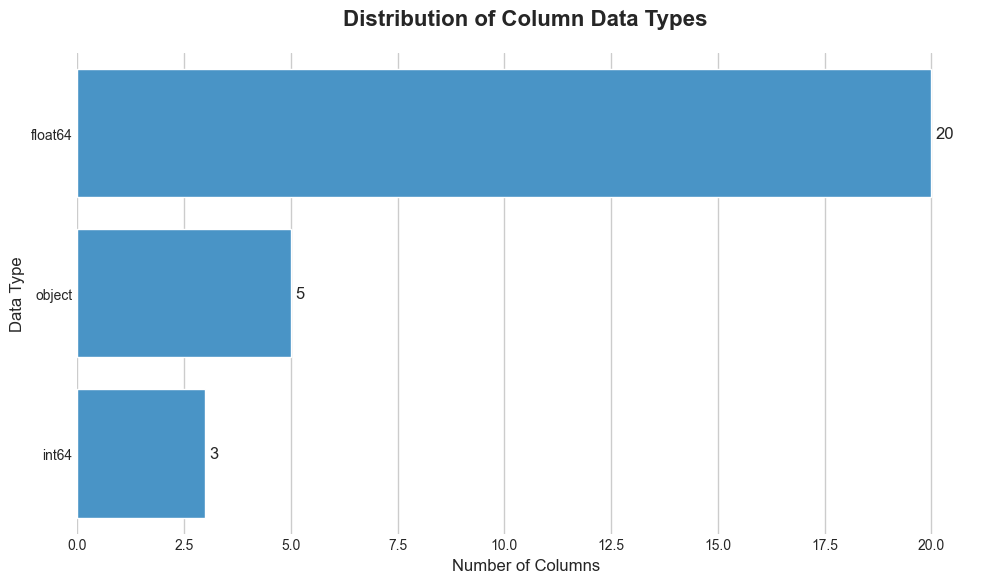

In [ ]:
data_types = train_df.dtypes.value_counts().reset_index()
data_types.columns = ['Dtype', 'Count']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=data_types,
    x='Count',
    y='Dtype',
    color="#3498db",
    legend=False
)

ax.bar_label(ax.containers[0], padding=3, fontsize=12)

plt.title('Distribution of Column Data Types', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Columns', fontsize=12)
plt.ylabel('Data Type', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "data_types_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Temporal Split and Panel Definition

The train/test partition is not random: it is explicitly time-based.  
This is a crucial design property because the modeling task aims to forecast future financial health rather than interpolate within the same observation window.

**Key structural findings**
- The training set covers historical firm observations up to the final in-sample years.
- The test set contains strictly later fiscal years, with **no year overlap** with the training period.
- Most companies are observed across multiple consecutive years, so the dataset should be treated as a **panel dataset**, not as independent rows.

**Why this matters:** a temporal split is methodologically correct for forecasting, but it also makes survivorship and panel completeness much more important than in a standard i.i.d. tabular problem.

In [ ]:
print("Train years:", sorted(train_df["fiscal_year"].unique()))
print("Test years: ", sorted(test_df["fiscal_year"].unique()))

print("\nUnique companies(train):", train_df["company_id"].nunique())
print("Unique companies (test): ", test_df["company_id"].nunique())

rows_per_company = train_df.groupby("company_id").size().value_counts().sort_index()
print("\nRows per company (train):\n", rows_per_company)

Train years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test years:  [np.int64(2022), np.int64(2023)]

Unique companies(train): 2999
Unique companies (test):  2916

Rows per company (train):
 1      20
2      24
3      60
4    2895
Name: count, dtype: int64


No year overlap between train and test. **96.5%** of companies have all 4 years, panel is nearly balanced.

### 1.4 Panel Completeness




A core requirement for panel-based feature engineering is that firms are observed across a sufficiently contiguous sequence of fiscal years.  
We therefore measure how many companies have the full expected history and isolate the subset with incomplete trajectories.

**High-level result**
- The panel is **strongly balanced overall**.
- Only a small minority of companies have incomplete yearly histories.
- This supports the use of **lagged**, **trend**, and **delta-based** features for most firms.

| Panel Completeness Check | Result | Interpretation |
|---|---:|---|
| Companies with full 4-year history | ~96.5% | The dataset is almost fully balanced |
| Companies with incomplete history | 104 / 2,999 | Missing trajectories are rare enough to inspect individually |
| Dominant pattern | Missing late years | Suggests economically meaningful exits rather than random coverage noise |

**Modeling implication**
- Lag-based feature engineering is structurally justified.
- Incomplete histories should **not** be dropped mechanically.
- Because incompleteness is concentrated in a small subset, it can be modeled explicitly as a potentially informative signal.


In [ ]:
full_years = set([2018, 2019, 2020, 2021])

company_years = train_df.groupby("company_id")["fiscal_year"].apply(set)
incomplete = company_years[company_years.apply(len) < 4]

print(f"Companies with incomplete history: {len(incomplete)} / {train_df['company_id'].nunique()}")

summary = pd.DataFrame({
    "years_present": incomplete,
    "years_missing": incomplete.apply(lambda y: sorted(full_years - y)),
    "n_years": incomplete.apply(len)
})

print("\nMissing year patterns:")
print(summary["years_missing"].value_counts())

Companies with incomplete history: 104 / 2999

Missing year patterns:
years_missing
[2018]                37
[2021]                23
[2020, 2021]          23
[2019, 2020, 2021]    20
[2018, 2021]           1
Name: count, dtype: int64


- **2021** is the most frequently missing fiscal year (**67 companies**).
- Missing years are therefore concentrated toward the **end of the panel**.
- This suggests that incomplete histories are more likely caused by firms **dropping out in later years** than by missing early observations.
- As a result, panel gaps may reflect meaningful events such as **financial distress, reporting interruption, or market exit**, rather than simple random missingness.

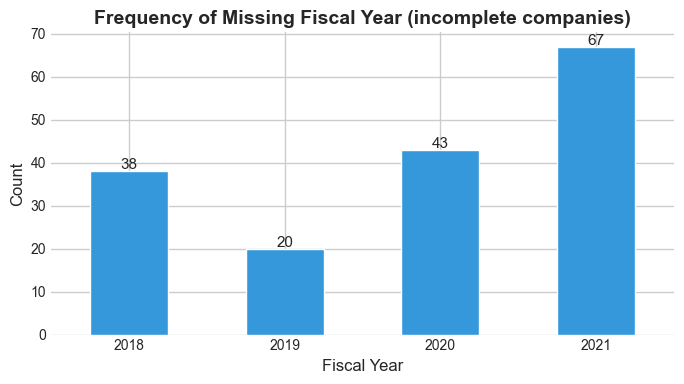

In [ ]:
all_missing = list(chain.from_iterable(summary["years_missing"]))
missing_counts = pd.Series(all_missing).value_counts().sort_index()

missing_counts.plot(kind="bar", color="#3498db", edgecolor="white", figsize=(7, 4))

for i, v in enumerate(missing_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.title("Frequency of Missing Fiscal Year (incomplete companies)")
plt.xlabel("Fiscal Year"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG_DIR / "missing_fiscal_year_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Internal Gap Check


Not all incomplete histories carry the same meaning.  
A firm may be incomplete because it has an **internal reporting gap** (e.g., 2018, 2020) or because it has a **contiguous history that stops early** (e.g., 2018–2019 only). These two cases have very different economic interpretations.

**Diagnostic logic**
1. Detect whether missing years occur **inside** the observed sequence.
2. Separate those cases from firms whose records remain contiguous but end before the full panel horizon.
3. Use this distinction to decide whether incompleteness is more consistent with reporting irregularity or genuine disappearance.

**Conclusion**
- Internal gaps are relatively limited.
- Most incomplete trajectories are better described as **early-ending contiguous histories** rather than fragmented reporting.
- This materially strengthens the hypothesis that many missing late years reflect **true exits** rather than noisy bookkeeping artifacts.

In [ ]:
# Check for year gaps within a company's history (e.g. 2018, 2020 — missing 2019)
def find_gaps(years):
    years = sorted(years)
    gaps = []
    for i in range(len(years) - 1):
        expected = years[i] + 1
        actual = years[i + 1]
        if actual != expected:
            gaps.append((years[i], actual))  # (last seen, next seen)
    return gaps

company_gaps = company_years.apply(find_gaps)
companies_with_gaps = company_gaps[company_gaps.apply(len) > 0]

print(f"Companies with year gaps: {len(companies_with_gaps)} / {train_df['company_id'].nunique()}")
print("\nGap patterns (from_year → to_year):")
print(companies_with_gaps.explode().value_counts())

Companies with year gaps: 0 / 2999

Gap patterns (from_year → to_year):
Series([], Name: count, dtype: int64)


- Missing years are more frequently concentrated at the **end** of a company’s observed history than at the start.
- The most common cases are firms whose last available year is **2018** or **2019**.
- By contrast, fewer firms appear to enter the dataset late and miss only the initial years.
- This suggests that panel incompleteness is more often driven by **early exit** than by random data coverage.
- Therefore, missing late years may carry useful information about **financial weakness or firm disappearance**.

In [ ]:
# For each incomplete company, check if missing years are at the start or end
def missing_position(years):
    years = sorted(years)
    missing = sorted(full_years - set(years))
    positions = []
    for y in missing:
        if y < years[0]:
            positions.append(f"start, {years[0]}")   # missing early years → entered dataset late
        elif y > years[-1]:
            positions.append(f"end, {years[-1]}")     # missing late years → exited dataset early
        else:
            positions.append("middle")  # impossible given no gaps, but safety check
    return positions

summary["missing_position"] = summary["years_present"].apply(missing_position)
print(summary["missing_position"].explode().value_counts())

missing_position
end, 2018      60
end, 2019      46
start, 2019    38
end, 2020      24
Name: count, dtype: int64


## Section 1: Findings
**104 companies have fewer than 4 years** in the training set:

| Pattern | Count | Interpretation |
|---|---|---|
| Missing at **end** (early exits) | 130 observations | Company stopped filing — likely distress |
| Missing at **start** (late entrants) | 38 observations | Young company, entered after 2018 |

**Early exits are strongly associated with class D:**

| Class | Early Exits | Full Dataset |
|-------|-------------|--------------|
| A     | 2.9%        | 8.5%         |
| B     | 13.1%       | 59.3%        |
| C     | 19.0%       | 23.2%        |
| D     | **65.0%**   | **8.9%**     |

65% of companies that disappeared before 2021 were class D — vs only 8.9% in the full dataset.  
This is **informative missingness**, not random. These companies stopped filing due to severe financial distress.

> **Survivorship bias**: companies present in the test set (2022–2023) are survivors by definition.  
> The model may underestimate D risk for companies that will exit mid-period. This is a known limitation.


### Time Dimension as an Asset: Lag Features

Since most companies have 4 consecutive years of contiguous data, we can engineer **trend features**  
that capture whether a company's financial health is improving or deteriorating.

A company with ROE dropping from `0.4 → 0.1` is riskier than one stable at `0.15`,  
even though the current value is higher. Raw snapshots miss this signal.

**Features to engineer (computed at year `t` using year `t-1`)**:

| Feature | Formula | Signal |
|---|---|---|
| `roe_prev` | `roe` at `t-1` | Profitability baseline |
| `roi_prev` | `roi` at `t-1` | Efficiency baseline |
| `current_ratio_prev` | `current_ratio` at `t-1` | Liquidity baseline |
| `roe_yoy` | `roe_t - roe_{t-1}` | Profitability trend |
| `roi_yoy` | `roi_t - roi_{t-1}` | Efficiency trend |
| `leverage_trend` | `leverage_t - leverage_{t-1}` | Increasing debt signal |
| `equity_growth` | `(equity_t - equity_{t-1}) / abs(equity_{t-1})` | Capital erosion signal |
| `is_last_observation` | 1 if final row for company | Exit/distress signal |
| `n_years_in_panel` | count of years in dataset | Short history = higher risk |

Late entrants (38 companies missing 2018) will have `NaN` lag features on their first row → imputed with median during preprocessing.  
`is_last_observation` and `n_years_in_panel` must be computed **before** the train/test split to avoid leakage.

### Cross-Validation Strategy

Standard k-fold CV is **not valid** here because it would leak future data into training.  
Use **time-based expanding window CV** on the training set:

| Fold | Train | Validation |
|---|---|---|
| 1 | 2018 | 2019 |
| 2 | 2018–2019 | 2020 |
| 3 | 2018–2020 | 2021 ← most important |

Use `sklearn.model_selection.TimeSeriesSplit` or build manually on `fiscal_year`.  
**Never shuffle** when splitting.

### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

## 2. Target Variable Analysis


After validating the structure of the panel, the next step is to examine the target variable itself. This section assesses class imbalance, temporal stability, and segment-level concentration in order to determine which evaluation metrics, categorical features, and feature-engineering strategies are justified downstream.

### 2.1 Why the Target Distribution Matters

In a multiclass financial-health problem, the target distribution is not a descriptive detail: it directly shapes metric selection, model calibration, and the interpretation of categorical effects. We therefore begin by checking whether the target is strongly imbalanced and whether that imbalance is stable across time and business segments.

In [ ]:
counts = train_df[TARGET].value_counts()
pcts   = train_df[TARGET].value_counts(normalize=True) * 100

print(pd.concat([counts, pcts.round(2)], axis=1, keys=["count", "%"]))

                        count      %
financial_health_class              
B                        7017  59.33
C                        2750  23.25
D                        1058   8.94
A                        1003   8.48


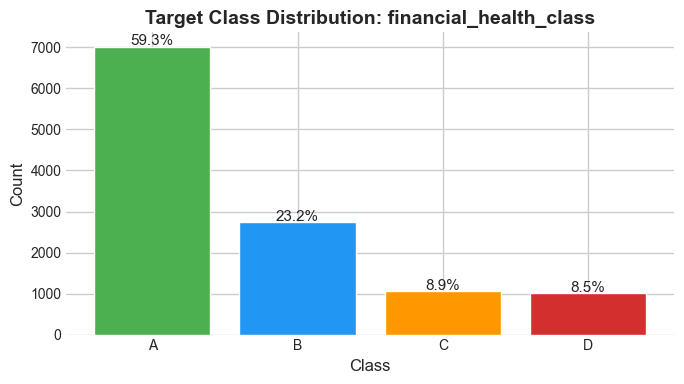

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
bars = ax.bar(CLASSES, counts, color=[palette[c] for c in CLASSES], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_title("Target Class Distribution: financial_health_class")
ax.set_xlabel("Class"); ax.set_ylabel("Count")

plt.savefig(OUTPUT_PATH / "Target Class Distribution: financial_health_class.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

### 2.2 Overall Class Balance

We first inspect the overall class composition of `financial_health_class` to determine whether the classification task is balanced or dominated by a single outcome.

| Class | Count | Share |
|---|---:|---:|
| A (Excellent) | 1,003 | 8.5% |
| B (Good) | 7,017 | 59.3% |
| C (Moderate Risk) | 2,750 | 23.3% |
| D (High Risk) | 1,058 | 8.9% |

The target is clearly imbalanced: **Class B** accounts for nearly three-fifths of all observations, while **Classes A and D** remain small minority groups. This means that raw accuracy would overstate model quality by rewarding majority-class predictions.

In [ ]:
# Compute
contingency_time = pd.crosstab(train_df['fiscal_year'], train_df[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency_time)
yearly_pct = contingency_time.div(contingency_time.sum(axis=1), axis=0) * 100

years_str = [str(y) for y in yearly_pct.index.tolist()]

colors    = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
sig_color = "#1B5E20" if p_value > 0.05 else "#d32f2f"
sig_label = "Not Significant ✓" if p_value > 0.05 else "Significant ✗"
verdict   = "Distribution stable over time" if p_value > 0.05 else "Temporal drift detected"

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.70, 0.30],
    subplot_titles=["Class Distribution by Fiscal Year", "Chi² Stability Test"],
    horizontal_spacing=0.08
)

for cls in reversed(CLASSES):
    vals = yearly_pct[cls].tolist()
    fig.add_trace(go.Bar(
        name=f"Class {cls}", x=years_str, y=vals,
        marker_color=colors[cls],
        text=[f"{v:.1f}%" for v in vals],
        textposition="inside",
        textfont=dict(color="white", size=13, family="Arial Black"),
    ), row=1, col=1)

fig.update_layout(barmode="stack")
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)

for y_pos, text, size, color in [
    (0.83, f"χ² = {chi2:.2f}",   28, "#000000"),
    (0.65, f"p = {p_value:.3f}", 26, sig_color),
    (0.49, f"dof = {dof}",       20, "#000000"),
    (0.32, sig_label,            18, sig_color),
    (0.14, verdict,              14, "#000000"),
]:
    fig.add_trace(go.Scatter(
        x=[0.5], y=[y_pos], mode="text",
        text=[f"<b>{text}</b>"],
        textfont=dict(size=size, color=color, family="Arial"),
        showlegend=False
    ), row=1, col=2)

fig.add_shape(
    type="rect", xref="x2", yref="y2",
    x0=0.02, y0=0.01, x1=0.98, y1=0.98,
    line=dict(color="#000000", width=3),
    fillcolor="white",
    layer="below"
)

fig.update_xaxes(visible=False, row=1, col=2)
fig.update_yaxes(visible=False, range=[0, 1], row=1, col=2)
fig.update_annotations(font=dict(size=15, color="#000000", family="Arial"))

fig.update_layout(
    height=600,
    width=1100,
    title={
        "text": (
        "<b>Target Distribution Stability (2018–2021)</b>"
        "<br>"   
        "<span style='font-size:15px; font-weight:normal; font-style:italic; color:#555555;'>"
        f"No significant temporal drift: χ²={chi2:.2f}, p={p_value:.3f}</span>"
        ),
        "x": 0.5,
        "xanchor": "center",
        "y": 0.93,       
        "yanchor": "top", 
        "pad": {"b": 20}, 
        "font": dict(size=22, color="#111111"),
    },
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.18,
        xanchor="center", x=0.35,
        traceorder="reversed",
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=150, b=90, l=70, r=60),
)

fig.write_image(FIG_DIR / "target_distribution_stability.png", scale=2)
fig.show()

The yearly class proportions remain broadly stable from 2018 to 2021, and the chi-square test does not indicate a statistically meaningful redistribution of classes across fiscal years. This is an important modeling result: the target does not exhibit strong temporal drift, so the train-period class structure appears sufficiently consistent for supervised learning.

**Modeling implication:** time-aware validation is still appropriate, but there is no evidence that major target reweighting is required purely because of fiscal-year instability.

### 2.3 Temporal Stability


In [ ]:
yearly_dist = train_df.groupby("fiscal_year")[TARGET].value_counts(normalize=True).unstack()
print(yearly_dist.round(3))

financial_health_class      A      B      C      D
fiscal_year                                       
2018                    0.086  0.613  0.216  0.085
2019                    0.087  0.593  0.232  0.088
2020                    0.081  0.590  0.235  0.094
2021                    0.085  0.577  0.247  0.091


## Section 2: Findings

### Class Imbalance

The dataset is strongly imbalanced:

| Class | Count | % |
|-------|------:|--:|
| A (Excellent)     | 1,003 |  8.5% |
| B (Good)          | 7,017 | 59.3% |
| C (Moderate Risk) | 2,750 | 23.3% |
| D (High Risk)     | 1,058 |  8.9% |

B dominates at 59.3%. A and D are the minority classes.  
**Accuracy is a misleading metric**, a trivial model predicting always B reaches 59% without learning anything.

→ Primary metric: **Weighted F1-Score**  
→ Apply `class_weight="balanced"` in all classifiers


### Temporal Stability: No Structural Drift

Chi² test on the yearly contingency table: **χ²=11.64, p=0.234**, year-over-year variation is not statistically significant.

| Year | A | B | C | D |
|------|--:|--:|--:|--:|
| 2018 | 8.6% | 61.3% | 21.6% | 8.5% |
| 2019 | 8.7% | 59.3% | 23.2% | 8.8% |
| 2020 | 8.1% | 59.0% | 23.5% | 9.4% |
| 2021 | 8.5% | 57.7% | 24.7% | 9.1% |

No spike in Class D during 2020–2021 despite COVID-19.  
→ `fiscal_year` has no demonstrated standalone predictive power. 

Include as a feature but expect near-zero importance.

### Low-Signal Categoricals: Legal Form & Region

Both features show minimal variation across classes (all within ±2pp of the global baseline).No legal form or region consistently produces a materially different class distribution.

**Legal Form:** All five forms (SRL, SPA, SAS, SNC, SAPA) are statistically indistinguishable.
No logical mechanism exists by which legal structure drives financial health independently of the financials themselves.  
→ **Consider dropping** rather than encoding, 4 dummy columns with no signal.

**Region:** Marginally more informative than legal form, but the range remains narrow (~5pp on
Class D). Notable exception: Liguria shows the highest C rate (27.7%) and lowest B rate (53.9%).  

→ **Encode but expect low importance.**  
→ Do **not** aggregate into macro-areas (Nord/Centro/Sud), with only 10 regions cardinality is not an issue, and aggregation destroys the small existing signal.



### ATECO Sector: Weak Standalone, Valuable for Feature Engineering

Statistical picture is mixed:
- **χ²=190.93, p=2.18e-29**: statistically significant
- **Mutual Info = 0.0096**: near-zero standalone discriminative power

Chi² scales with sample size: even tiny differences become "significant" at n=11,828. MI
measures actual information content and is sample-size agnostic. The real signal is not in
Class D (range: 5.1%–9.6%, only 4.5pp spread) but in the **A/C axis**:

| Sector | Profile |
|--------|---------|
| Construction (41, 43) | C=29–30%, A=6%: chronic deterioration, high debt |
| Real Estate (68) | **A=0.0%**: structurally never excellent |
| IT Services (62) | D=6.4%: knowledge-based resilience |
| Wholesale Trade (46, 47) | A=10–11%: healthier cash flow |

→ Keep `ateco_sector` at full granularity.  
→ Primary value: **sector-relative feature engineering**
  (e.g. `roe - sector_median_roe`) to capture peer-relative performance.  
→ **Important:** sector medians must be computed on train only, computing on the full dataset
  is data leakage.


### Preprocessing Decisions from Section 2

| Decision | Rationale |
|----------|-----------|
| Weighted F1 as primary metric | Accuracy misleading under 59% imbalance |
| `class_weight="balanced"` in all models | Prevents majority-class dominance |
| Keep `fiscal_year` as feature | No strong signal, but zero cost to include |
| **Consider dropping `legal_form`** | No signal, no logical mechanism, 4 dummy columns wasted |
| Encode `region` at full granularity | Weak signal, 10 categories — cardinality not an issue |
| Keep `ateco_sector` at full granularity | Meaningful for peer-relative feature engineering |
| Engineer sector-relative ratios | Captures performance vs peers, not absolute levels |
| Compute sector medians on train set only | Prevents leakage into test set |

## 3. Missing Values

Missingness is not automatically a data-cleaning issue in financial data: it can reflect either **true data absence** or **economically meaningful conditions**. 

This section distinguishes between **structural missingness** (where nulls encode distress) and **benign missingness** (where nulls behave like random administrative gaps), so that each feature can be handled with the correct preprocessing strategy.

### 3.1 Diagnostic Scope

We evaluate missingness along four dimensions:

1. **Column-level prevalence**: how much missing data each feature contains.
2. **Economic structure**: whether nulls arise from a valid financial condition (e.g. negative equity).
3. **Target dependence**: whether missingness is associated with `financial_health_class`.
4. **Temporal stability**: whether the pattern changes across fiscal years.

### 3.2 Integrated Missingness Diagnostics

The figure below combines all missing-value checks in one place: overall missingness rates, the class profile of null `roe`, the concentration of negative equity by class, the class distribution of missing `province`, and year-by-year stability for both structural and non-structural nulls. This layout is intentional: the goal is to separate **signal-bearing nulls** from **harmless categorical gaps** before choosing an imputation strategy.

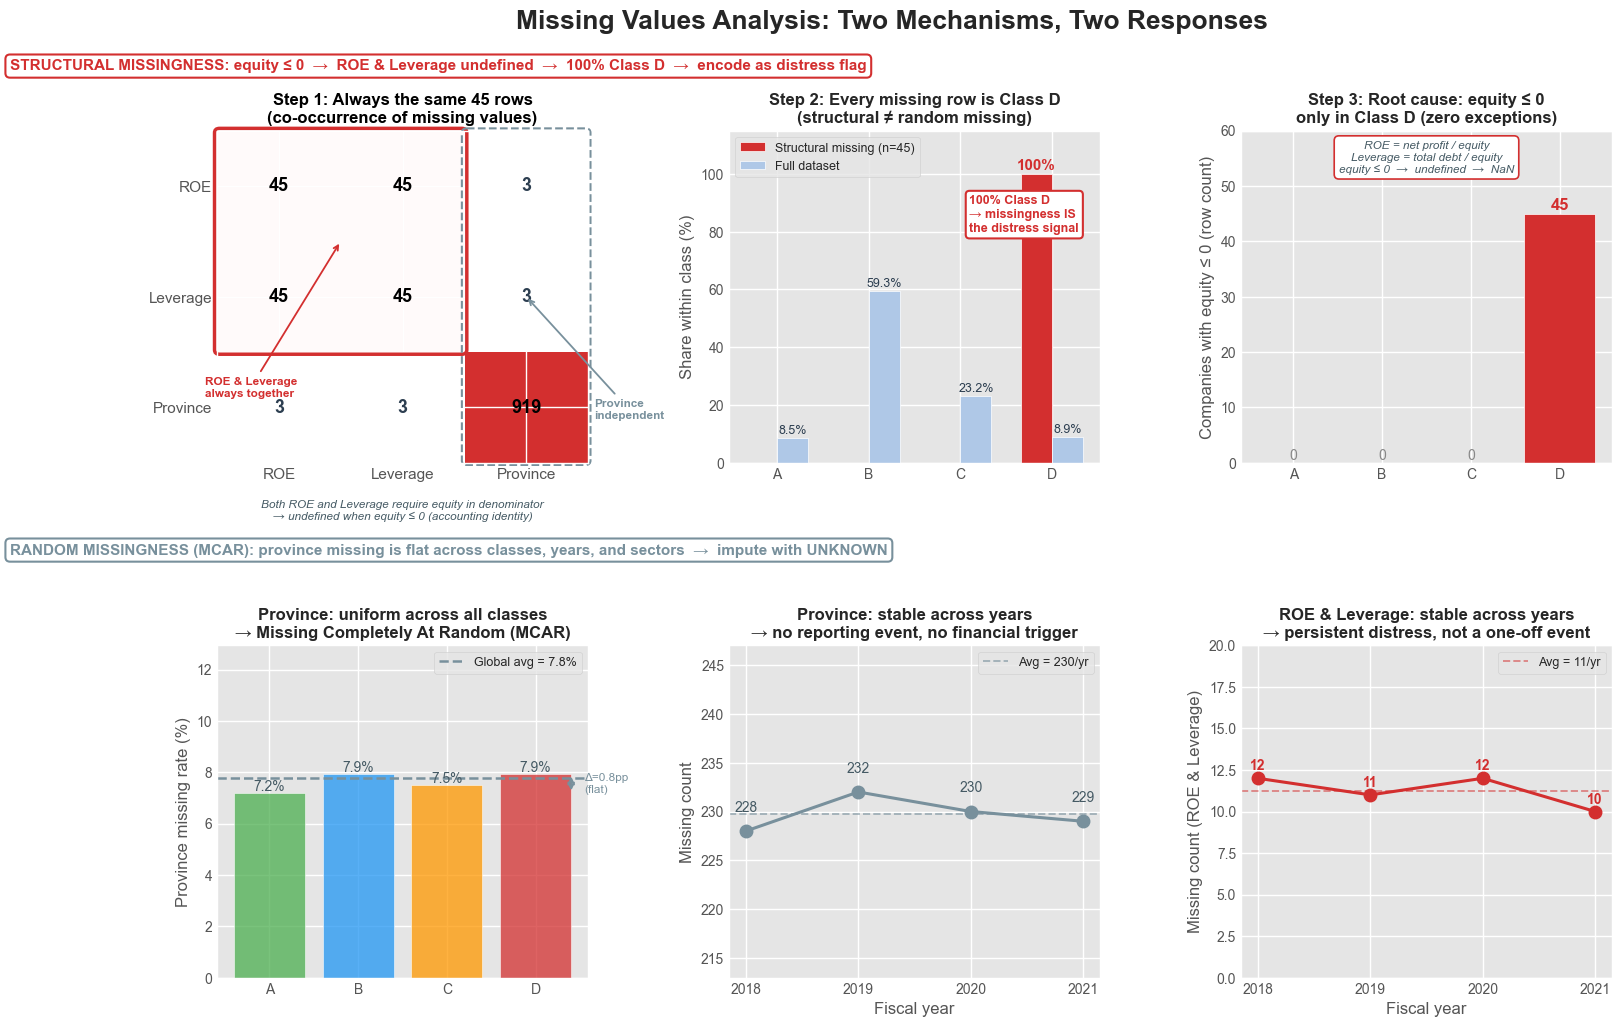

saved: missing_analysis_improved.png


In [ ]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct     = (missing / len(train_df) * 100).round(2)

assert (train_df["roe"].isnull() == train_df["leverage"].isnull()).all(), \
    "ROE and leverage nulls are NOT on the same rows — check data"

mask_structural = train_df["roe"].isnull()
n_structural    = mask_structural.sum()


train_df["_neg_eq"] = (train_df["shareholders_equity"] < 0).astype(int)
neg_by_class = train_df.groupby(TARGET)["_neg_eq"].sum().reindex(CLASSES, fill_value=0)
pct_neg_eq_is_structural = (
    (train_df["_neg_eq"] == 1).sum() == n_structural
)  
train_df.drop(columns="_neg_eq", inplace=True)


class_dist_null = (
    train_df[mask_structural][TARGET]
    .value_counts(normalize=True).reindex(CLASSES, fill_value=0) * 100
)
class_dist_full = (
    train_df[TARGET]
    .value_counts(normalize=True).reindex(CLASSES, fill_value=0) * 100
)


features_to_check = ["roe", "leverage", "province"]
co_matrix = pd.DataFrame(index=features_to_check, columns=features_to_check, dtype=float)
for f1 in features_to_check:
    for f2 in features_to_check:
        co_matrix.loc[f1, f2] = (train_df[f1].isnull() & train_df[f2].isnull()).sum()


train_df["_prov_miss"] = train_df["province"].isnull().astype(int)
prov_rate_by_class = (
    train_df.groupby(TARGET)["_prov_miss"].mean()
    .reindex(CLASSES, fill_value=0) * 100
)
train_df.drop(columns="_prov_miss", inplace=True)

prov_by_year = train_df.groupby("fiscal_year")["province"].apply(lambda x: x.isnull().sum())
roe_by_year  = train_df.assign(_s=mask_structural.astype(int)).groupby("fiscal_year")["_s"].sum()
global_prov_rate = train_df["province"].isnull().mean() * 100
years = [str(y) for y in prov_by_year.index]


plt.style.use("ggplot")
palette        = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
class_colors   = [palette[c] for c in CLASSES]
structural_red = "#d32f2f"
mcar_grey      = "#78909C"
full_color     = "#AFC8E7"


fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])


# PLOT 1: Co-occurrence matrix
cmap_co = mcolors.LinearSegmentedColormap.from_list(
    "miss", ["#ffffff", "#FFCDD2", structural_red]
)
ax1.imshow(co_matrix.values.astype(float), cmap=cmap_co, aspect="auto", vmin=0)

for i in range(3):
    for j in range(3):
        val   = int(co_matrix.values[i, j])
        color = "black" if val > 25 else "#2c3e50"
        ax1.text(j, i, str(val), ha="center", va="center",
                 fontsize=13, fontweight="bold", color=color)

ax1.set_xticks(range(3))
ax1.set_yticks(range(3))
ax1.set_xticklabels(["ROE", "Leverage", "Province"], fontsize=11)
ax1.set_yticklabels(["ROE", "Leverage", "Province"], fontsize=11)
ax1.set_title("Step 1: Always the same 45 rows\n(co-occurrence of missing values)",
              fontweight="bold", fontsize=12, color="#000000" if False else "black")


rect = FancyBboxPatch((-0.48, -0.48), 1.96, 1.96,
                      boxstyle="round,pad=0.04",
                      linewidth=2.5, edgecolor=structural_red, facecolor="none",
                      transform=ax1.transData, clip_on=False)
ax1.add_patch(rect)

rect2 = FancyBboxPatch((1.52, -0.48), 0.96, 2.96,
                       boxstyle="round,pad=0.04",
                       linewidth=1.5, edgecolor=mcar_grey,
                       linestyle="--", facecolor="none",
                       transform=ax1.transData, clip_on=False)
ax1.add_patch(rect2)

ax1.annotate("ROE & Leverage\nalways together",
             xy=(0.5, 0.5), xytext=(-0.6, 1.9),
             fontsize=8.5, color=structural_red, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=structural_red, lw=1.3))

ax1.annotate("Province\nindependent",
             xy=(2, 1), xytext=(2.55, 2.1),
             fontsize=8.5, color=mcar_grey, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=mcar_grey, lw=1.3))

ax1.text(0.5, -0.17,
         "Both ROE and Leverage require equity in denominator\n"
         "→ undefined when equity ≤ 0 (accounting identity)",
         transform=ax1.transAxes, ha="center", fontsize=8.5,
         color="#455A64", style="italic")


# PLOT 2: Class distribution: structural missing vs full dataset
x = np.arange(len(CLASSES))
w = 0.34

bars_null = ax2.bar(x - w/2, class_dist_null.values, width=w,
                    color=structural_red, edgecolor="white",
                    label=f"Structural missing (n={n_structural})")
bars_full = ax2.bar(x + w/2, class_dist_full.values, width=w,
                    color=full_color, edgecolor="white",
                    label="Full dataset")

for i, (v1, v2) in enumerate(zip(class_dist_null.values, class_dist_full.values)):
    if v1 > 0:
        ax2.text(i - w/2, v1 + 1.5, f"{v1:.0f}%", ha="center",
                 fontsize=11, fontweight="bold", color=structural_red)
    if v2 > 2:
        ax2.text(i + w/2, v2 + 1.5, f"{v2:.1f}%", ha="center",
                 fontsize=9, color="#2c3e50")

ax2.annotate("100% Class D\n→ missingness IS\nthe distress signal",
             xy=(3 - w/2, 100), xytext=(2.1, 80),
             fontsize=9, color=structural_red, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=structural_red, lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=structural_red, lw=1.5))

ax2.set_xticks(x)
ax2.set_xticklabels(CLASSES)
ax2.set_ylim(0, 115)
ax2.set_ylabel("Share within class (%)")
ax2.set_title("Step 2: Every missing row is Class D\n(structural ≠ random missing)",
              fontweight="bold", fontsize=12)
ax2.legend(fontsize=9, frameon=True, loc="upper left")


# PLOT 3: Root cause: negative equity by class
bars3 = ax3.bar(CLASSES, neg_by_class.values, color=class_colors, edgecolor="white")

for i, v in enumerate(neg_by_class.values):
    if v > 0:
        ax3.text(i, v + 0.8, str(int(v)), ha="center",
                 fontsize=12, fontweight="bold", color=structural_red)
    else:
        ax3.text(i, 0.5, "0", ha="center", fontsize=10, color="#888")

ax3.text(0.5, 0.97,
         "ROE = net profit / equity\n"
         "Leverage = total debt / equity\n"
         "equity ≤ 0  →  undefined  →  NaN",
         transform=ax3.transAxes, ha="center", va="top",
         fontsize=8.5, style="italic", color="#455A64",
         bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff", ec=structural_red, lw=1.2))

ax3.set_ylabel("Companies with equity ≤ 0 (row count)")
ax3.set_ylim(0, max(neg_by_class.values) + 15)
ax3.set_title("Step 3: Root cause: equity ≤ 0\nonly in Class D (zero exceptions)",
              fontweight="bold", fontsize=12)


# PLOT 4: Province missing rate by class (MCAR evidence)
bars4 = ax4.bar(CLASSES, prov_rate_by_class.values, color=class_colors,
                edgecolor="white", alpha=0.75)

for i, v in enumerate(prov_rate_by_class.values):
    ax4.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=10, color="#455A64")

ax4.axhline(y=global_prov_rate, color=mcar_grey, linestyle="--", linewidth=1.8,
            label=f"Global avg = {global_prov_rate:.1f}%")


min_r = prov_rate_by_class.values.min()
max_r = prov_rate_by_class.values.max()
ax4.annotate("", xy=(3.4, max_r), xytext=(3.4, min_r),
             arrowprops=dict(arrowstyle="<->", color=mcar_grey, lw=1.5))
ax4.text(3.55, (max_r + min_r) / 2,
         f"Δ={max_r-min_r:.1f}pp\n(flat)", fontsize=8.5,
         color=mcar_grey, va="center")

ax4.set_ylabel("Province missing rate (%)")
ax4.set_ylim(0, max(prov_rate_by_class.values) + 5)
ax4.set_title("Province: uniform across all classes\n→ Missing Completely At Random (MCAR)",
              fontweight="bold", fontsize=12)
ax4.legend(fontsize=9, frameon=True)


# PLOT 5:Province missing by year (MCAR temporal stability)
ax5.plot(years, prov_by_year.values, marker="o", color=mcar_grey,
         linewidth=2.2, markersize=9)

for y, v in zip(years, prov_by_year.values):
    ax5.text(y, v + 2, str(v), ha="center", fontsize=10, color="#455A64")

ax5.axhline(y=prov_by_year.mean(), color=mcar_grey, linestyle="--",
            linewidth=1.4, alpha=0.6, label=f"Avg = {prov_by_year.mean():.0f}/yr")

ax5.set_ylabel("Missing count")
ax5.set_xlabel("Fiscal year")
ax5.set_ylim(min(prov_by_year.values) - 15, max(prov_by_year.values) + 15)
ax5.set_title("Province: stable across years\n→ no reporting event, no financial trigger",
              fontweight="bold", fontsize=12)
ax5.legend(fontsize=9, frameon=True)


# PLOT 6: ROE/leverage missing by year
ax6.plot(years, roe_by_year.values, marker="o", color=structural_red,
         linewidth=2.2, markersize=9)

for y, v in zip(years, roe_by_year.values):
    ax6.text(y, v + 0.5, str(v), ha="center", fontsize=10,
             fontweight="bold", color=structural_red)

ax6.axhline(y=roe_by_year.mean(), color=structural_red, linestyle="--",
            linewidth=1.4, alpha=0.5, label=f"Avg = {roe_by_year.mean():.0f}/yr")

ax6.set_ylabel("Missing count (ROE & Leverage)")
ax6.set_xlabel("Fiscal year")
ax6.set_ylim(0, max(roe_by_year.values) + 8)
ax6.set_title("ROE & Leverage: stable across years\n→ persistent distress, not a one-off event",
              fontweight="bold", fontsize=12)
ax6.legend(fontsize=9, frameon=True)

fig.suptitle(
    "Missing Values Analysis: Two Mechanisms, Two Responses",
    fontsize=19, fontweight="bold", y=0.99
)

# Section banners
fig.text(0.01, 0.935,
         "STRUCTURAL MISSINGNESS: equity ≤ 0  →  ROE & Leverage undefined  →  100% Class D  →  encode as distress flag",
         fontsize=11, fontweight="bold", color=structural_red,
         bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec=structural_red, lw=1.5))

fig.text(0.01, 0.495,
         "RANDOM MISSINGNESS (MCAR): province missing is flat across classes, years, and sectors  →  impute with UNKNOWN",
         fontsize=11, fontweight="bold", color=mcar_grey,
         bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", ec=mcar_grey, lw=1.5))


plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("missing_analysis_improved.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: missing_analysis_improved.png")

### 3.3 Interpretation

The missing-value structure is highly asymmetric:

- **`roe` and `leverage` nulls are structural**, not accidental.
- They occur on the **same 45 observations**, all tied to **negative shareholders' equity**.
- Those rows are concentrated entirely in **class D**, making the null pattern itself a **distress signal** rather than a data-quality defect.
- By contrast, **`province` missingness is materially larger but behaviorally neutral**: its rate is stable across classes and fiscal years, which is consistent with a benign administrative omission.

This is the key preprocessing conclusion of the section:

| Missingness Type | Features | Interpretation | Recommended Handling |
|---|---|---|---|
| **Structural / informative** | `roe`, `leverage` | Nulls encode economically meaningful distress | Preserve signal with missing indicators + controlled imputation |
| **Benign / near-random** | `province` | Missingness behaves like a non-informative categorical gap | Impute as explicit category (`"UNKNOWN"`) |

The important modeling mistake to avoid here is treating all nulls the same. In this dataset, some missing values are **predictive features**, while others are simply **categorical incompleteness**.

## Section 3: Findings

### Two Mechanisms, Two Responses

Only **three columns** contain missing values — the dataset is exceptionally clean:

| Column | Missing | % | Type | Interpretation |
|--------|--------:|--:|------|----------------|
| `province` | 919 | 7.77% | Benign / MCAR | Administrative categorical gap |
| `roe` | 45 | 0.38% | Structural | Undefined under negative equity |
| `leverage` | 45 | 0.38% | Structural | Uninterpretable under negative equity |

No balance sheet or income statement variables are missing. The only meaningful nulls occur in **derived ratios**, not raw accounting data.

### `roe` & `leverage`: Structural Missingness, Not Data Loss

All 45 null `roe` rows are **exactly the same rows** as the 45 null `leverage` rows,
and all correspond to **negative shareholders' equity**:

- `roe = net_profit / equity` → undefined when equity ≤ 0
- `leverage = total_debt / equity` → uninterpretable when equity ≤ 0
- The dataset correctly records these as `NaN` rather than exposing a
  mathematically valid but economically meaningless ratio

| Structural Fact | Modeling Meaning |
|-----------------|-----------------|
| `roe` null = `leverage` null on the same rows | One condition drives both null patterns |
| All affected rows have negative equity | Missingness is economically grounded |
| **100% of null rows are Class D** | Missingness itself is predictive |

These nulls are **not a data quality problem — they are a high-precision distress indicator.**
Do **not** median-impute `roe` or `leverage` blindly. That erases one of the clearest distress signals in the dataset.



### Negative Equity: High Precision, Low Recall

Negative equity is **exclusive to Class D**, but covers only a small subset of all
distressed observations:

| Signal Property | Interpretation |
|-----------------|---------------|
| **Precision = extremely high** | When it fires, the company is already in severe distress |
| **Recall = low** | Most Class D companies do **not** have negative equity yet |
| **Economic meaning** | Late-stage distress marker, not an early warning feature |

→ Preserve this signal. Do **not** rely on it alone — the bulk of Class D detection must still come from worsening profitability rising leverage, and deteriorating trends.

### `province`: Benign Categorical Missingness

`province` is the largest gap in absolute terms but behaviorally neutral:
- Missing rate is **flat across all four classes** (Δ < 1pp from global average)
- Missing rate is **stable across all four fiscal years**
- No evidence of concentration in any risk state

→ This is administrative incompleteness, not financial signal.

| Treatment | Why |
|-----------|-----|
| Impute with `"UNKNOWN"` | Preserves rows, respects categorical structure |
| Do **not** mode-impute | Would inject a fake geographic signal |
| Do **not** drop rows | Missingness is too common and non-harmful |


### Preprocessing Decisions from Section 3

| Decision | Rationale |
|----------|-----------|
| Create `roe_is_null`, `leverage_is_null` binary flags | Preserves the distress signal explicitly |
| Keep `shareholders_equity < 0` as an additional feature | Redundant with null flags but reinforces late-stage signal |
| Do **not** median-impute `roe` or `leverage` directly | Would erase a high-precision Class D indicator |
| Impute `province` as `"UNKNOWN"` category | Neutral gap — treat as a standard categorical level |
| No intervention needed for all other features | Dataset is clean outside these three columns |

→ Missing-value handling must be **economically informed**, not mechanically uniform.

## 4. Categorical Features

Categorical variables, legal form, region, and ATECO sector: are evaluated along two dimensions: standalone predictive signal and potential value for feature engineering.

The key question is whether these administrative descriptors discriminate between financial-health classes on their own, or whether their value only emerges through interaction with financial ratios.


### 4.1 Diagnostic Scope
We evaluate each categorical feature along three dimensions:

1. **Class separation**: does the class mix vary meaningfully across categories?
2. **Standalone predictive power**: quantified via Mutual Information against the target.
3. **Contextual engineering value**: does sector-relative normalisation of financial ratios increase predictive power beyond the raw ratio alone?

### 4.2 Segment-Level Variation: Legal Form and Region
We inspect whether broad administrative descriptors produce meaningfully different class distributions across their categories. If the class mix is visually near-identical across groups, these variables are unlikely to provide strong standalone signal and can at most contribute through interaction effects with financial ratios 

In [ ]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Class Distribution by Legal Form", "Class Distribution by Region"],
    horizontal_spacing=0.08,
    column_widths=[0.35, 0.65]
)

# Legal Form
legal = pd.crosstab(train_df["legal_form"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=legal.index.tolist(),
        y=(legal[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in legal[cls]],
        textposition="inside",
        textfont=dict(color="white", size=11),
        showlegend=True,
        legendgroup=cls,
    ), row=1, col=1)

# Region
region = pd.crosstab(train_df["region"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=region.index.tolist(),
        y=(region[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in region[cls]],
        textposition="inside",
        textfont=dict(color="white", size=10),
        showlegend=False,
        legendgroup=cls,
    ), row=1, col=2)

fig.update_layout(
    barmode="stack",
    title={
        "text": "<b>Low-Signal Categoricals: Legal Form & Region</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22, color="#000000")
    },
    legend=dict(
    orientation="h",
    yanchor="top",
    y=-0.35,
    xanchor="center",
    x=0.42,  
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1700,
    height=580,
    margin=dict(t=160, b=170, l=60, r=40),
)

fig.update_xaxes(title_text="Legal Form", row=1, col=1)
fig.update_xaxes(title_text="Region", tickangle=-20,title_standoff=0, row=1, col=2)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=2)

fig.write_image(str(OUTPUT_PATH / "low_signal_categoricals.png"), scale=2)
fig.show()

The class composition is visually similar across legal forms and across regions, with no segment showing a sharply different risk structure. 

This suggests that these variables have limited standalone discriminative value. 

They may still contribute marginally when combined with firm-level financial ratios, but they do not appear strong enough to drive separation on their own.

Broad categorical descriptors should therefore be treated as weak contextual features, not as core predictors.

### 4.3 ATECO Sector: Standalone Signal vs. Engineering Value

Sector membership is more economically motivated than legal form or geography and deserves separate treatment. 

The objective here is twofold: test the association with the target, and determine whether sector context adds value beyond the raw financial ratios when used for normalisation.

In [ ]:
# Sector name mapping
ateco_map = {
    (10, 33): "Manufacturing",
    (41, 43): "Construction",
    (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food",
    (58, 63): "Information & Communication",
    (68, 68): "Real Estate",
    (69, 75): "Professional & Scientific",
    (77, 82): "Admin & Support"
}

def get_sector_name(code):
    code_int = int(code)
    for (lo, hi), name in ateco_map.items():
        if lo <= code_int <= hi:
            return name
    return "Other"

# Data preparation
train_df["sector_name"] = (
    train_df["ateco_sector"]
    .astype(str)
    .str.zfill(2)
    .apply(get_sector_name)
)
contingency = pd.crosstab(train_df["sector_name"], train_df[TARGET])
chi2_val, p_val, dof, _ = chi2_contingency(contingency)
cross = pd.crosstab(
    train_df["sector_name"],
    train_df[TARGET],
    normalize="index"
) * 100
cross = cross[CLASSES].round(1)
X_enc = LabelEncoder().fit_transform(train_df["sector_name"])
y_enc = LabelEncoder().fit_transform(train_df[TARGET])
mi = mutual_info_classif(
    X_enc.reshape(-1, 1),
    y_enc,
    discrete_features=True
)[0]

print(f"Chi²={chi2_val:.2f}, p={p_val:.2e}, dof={dof}")
print(f"Mutual Info={mi:.4f}")
print(f"\nClass % by sector:\n{cross.sort_values('D', ascending=False)}")

# Ordering
sector_order = cross["D"].sort_values(ascending=False).index.tolist()
cross_sorted = cross.loc[sector_order]

global_d = train_df[TARGET].value_counts(normalize=True)["D"] * 100
max_d = max(cross_sorted["D"].max(), global_d)

# Figure
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.43, 0.57],
    horizontal_spacing=0.18,
    subplot_titles=[
        "Class D % by Sector",
        "Full Class Distribution Heatmap (%)"
    ]
)

# D% horizontal bar
fig.add_trace(
    go.Bar(
        x=cross_sorted["D"],
        y=cross_sorted.index,
        orientation="h",
        marker=dict(color="#d32f2f"),
        text=[f"{v:.1f}%" for v in cross_sorted["D"]],
        textposition="inside",
        insidetextanchor="end",
        textfont=dict(color="white", size=12),
        hovertemplate="<b>%{y}</b><br>Class D: %{x:.1f}%<extra></extra>",
        showlegend=False
    ),
    row=1, col=1
)

# Global D reference line
fig.add_vline(
    x=global_d,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    row=1, col=1
)

fig.add_annotation(
    x=global_d,
    y=1.08,
    xref="x1",
    yref="y domain",
    text=f"Global D = {global_d:.1f}%",
    showarrow=False,
    font=dict(size=12, color="gray"),
    bgcolor="rgba(255,255,255,0.85)",
    bordercolor="gray",
    borderwidth=1
)

fig.update_xaxes(
    title_text="Class D (%)",
    range=[0, max_d + 2.0],
    showgrid=True,
    gridcolor="rgba(0,0,0,0.08)",
    zeroline=False,
    row=1, col=1
)

fig.update_yaxes(
    title_text="Sector",
    autorange="reversed",
    tickfont=dict(size=12),
    row=1, col=1
)

# Heatmap
fig.add_trace(
    go.Heatmap(
        z=cross_sorted[CLASSES].values,
        x=CLASSES,
        y=cross_sorted.index,
        colorscale="RdYlGn_r",
        zmin=0,
        zmax=float(cross_sorted[CLASSES].values.max()),
        text=cross_sorted[CLASSES].values,
        texttemplate="%{text:.1f}%",
        textfont=dict(size=12, color="white"),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Class %{x}: %{z:.1f}%<extra></extra>"
        ),
        colorbar=dict(
            title="%",
            thickness=16,
            len=0.82,
            x=1.02,
            y=0.5
        )
    ),
    row=1, col=2
)

fig.update_xaxes(
    title_text="Health Class",
    side="bottom",
    tickfont=dict(size=12),
    row=1, col=2
)

fig.update_yaxes(
    tickfont=dict(size=12),
    autorange="reversed",
    row=1, col=2
)

# Layout
fig.update_layout(
    width=1550,
    height=720,
    template="plotly_white",
    title=dict(
        text=(
            "<b>ATECO Sector: Discriminative Power Analysis</b>"
            "<br>"
            f"<i><span style='font-size:15px; color:#444444;'>"
            f"χ² = {chi2_val:.1f}, p = {p_val:.2e}, "
            f"Mutual Information = {mi:.4f}"
            f"</span></i>"
        ),
        x=0.5,
        xanchor="center",
        y=0.95,
        yanchor="top",
        font=dict(size=22, color="#000000"),
    ),
    margin=dict(l=170, r=90, t=180, b=80),
    bargap=0.18
)

# Subplot titles font
for ann in fig["layout"]["annotations"]:
    if ann["text"] in ["Class D % by Sector", "Full Class Distribution Heatmap (%)"]:
        ann["font"] = dict(size=16, color="#000000")

fig.show()
fig.write_image(FIG_DIR / "ateco_sector_analysis.png", scale=2)

Chi²=190.93, p=2.18e-29, dof=21
Mutual Info=0.0096

Class % by sector:
financial_health_class          A     B     C    D
sector_name                                       
Construction                  6.0  54.9  29.5  9.6
Accommodation & Food          9.8  58.2  22.5  9.4
Admin & Support               9.4  60.5  20.8  9.4
Manufacturing                 8.5  60.3  22.0  9.3
Wholesale & Retail           10.6  60.2  19.9  9.3
Professional & Scientific     8.2  63.9  19.6  8.2
Information & Communication   9.2  62.0  22.4  6.4
Real Estate                   0.0  63.3  31.6  5.1


In [ ]:
categorical_features = ["legal_form", "region", "sector_name"]
TARGET = "financial_health_class"

df_mi = train_df[categorical_features + [TARGET]].dropna()


y_enc = LabelEncoder().fit_transform(df_mi[TARGET])

print("Standalone Mutual Information (Predictive Power)")
for cat in categorical_features:
    X_enc = LabelEncoder().fit_transform(df_mi[cat]).reshape(-1, 1)
    
    mi_score = mutual_info_classif(X_enc, y_enc, discrete_features=True, random_state=42)[0]
    
    print(f"{cat:<15}: {mi_score:.5f}")

Standalone Mutual Information (Predictive Power)
legal_form     : 0.00024
region         : 0.00160
sector_name    : 0.00959


In [ ]:
df = train_df.copy()

ateco_map = {
    (10, 33): "Manufacturing", (41, 43): "Construction", (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food", (58, 63): "Information & Communication",
    (68, 68): "Real Estate", (69, 75): "Professional & Scientific", (77, 82): "Admin & Support"
}

def get_sector_name(code):
    try:
        code_int = int(code)
        for (lo, hi), name in ateco_map.items():
            if lo <= code_int <= hi: return name
    except: pass
    return "Other"

df["sector_name"] = df["ateco_sector"].astype(str).str.zfill(2).apply(get_sector_name)

exclude_cols = ["company_id", "proxy_id", "fiscal_year", "ateco_sector", TARGET]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

df_mi_calc = df[num_cols + [TARGET]].dropna()
y_enc_full = LabelEncoder().fit_transform(df_mi_calc[TARGET])

mi_raw_all = mutual_info_classif(df_mi_calc[num_cols], y_enc_full, random_state=42)
mi_series = pd.Series(mi_raw_all, index=num_cols).sort_values(ascending=False)

TOP_5_FEATURES = mi_series.head(5).index.tolist()

df_sec = df[["sector_name", TARGET]].dropna()
X_sec_enc = LabelEncoder().fit_transform(df_sec["sector_name"]).reshape(-1, 1)
y_sec_enc = LabelEncoder().fit_transform(df_sec[TARGET])
mi_sector_standalone = mutual_info_classif(X_sec_enc, y_sec_enc, discrete_features=True, random_state=42)[0]

mi_results = []
df_clean = df.dropna(subset=TOP_5_FEATURES + ["sector_name", TARGET]).copy()
y_enc_clean = LabelEncoder().fit_transform(df_clean[TARGET])

for col in TOP_5_FEATURES:
    mi_raw = mutual_info_classif(df_clean[[col]], y_enc_clean, random_state=42)[0]
    med_col = df_clean.groupby("sector_name")[col].transform("median")
    df_clean[f"{col}_rel_med"] = df_clean[col] - med_col
    mi_rel = mutual_info_classif(df_clean[[f"{col}_rel_med"]], y_enc_clean, random_state=42)[0]
    mi_results.append({
        "Feature": col,
        "MI_Raw": mi_raw,
        "MI_Relative": mi_rel,
        "Boost_Pct": ((mi_rel - mi_raw) / mi_raw) * 100 if mi_raw > 0 else 0
    })

results_df = pd.DataFrame(mi_results).sort_values(by="MI_Raw", ascending=True)

# Figure
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.45, 0.55],
    horizontal_spacing=0.15,
    subplot_titles=[
        "1. Standalone Power: Sector vs. Financial Features",
        "2. Contextual Power: Boost via Sector-Median Normalization"
    ]
)

names  = ["Sector Label (Categorical)"] + results_df["Feature"].tolist()
values = [mi_sector_standalone] + results_df["MI_Raw"].tolist()
bar_colors = ["#d32f2f"] + ["#2196f3"] * len(results_df)

fig.add_trace(
    go.Bar(
        x=values,
        y=names,
        orientation="h",
        marker_color=bar_colors,
        text=[f"{v:.4f}" for v in values],
        textposition="outside",
        textfont=dict(color="#000000"),
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        name="Raw Feature",
        x=results_df["Feature"],
        y=results_df["MI_Raw"],
        marker_color="#BDC3C7",
        text=[f"{v:.3f}" for v in results_df["MI_Raw"]],
        textposition="outside",
        textfont=dict(color="#000000"),
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        name="Adjusted by Sector Median",
        x=results_df["Feature"],
        y=results_df["MI_Relative"],
        marker_color="#4caf50",
        text=[f"{v:.3f}<br>(+{b:.0f}%)" if b > 0 else f"{v:.3f}<br>({b:.0f}%)"
              for v, b in zip(results_df["MI_Relative"], results_df["Boost_Pct"])],
        textposition="outside",
        textfont=dict(color="#000000"),
    ),
    row=1, col=2
)

fig.update_layout(
    width=1600,
    height=680,
    template="plotly_white",
    title=dict(
        text=(
            "<b>The Supremacy of Absolute Financials Over Sector Context</b>"
            "<br>"
            "<i><span style='font-size:15px; color:#000000;'>"
            "Sector label has negligible standalone power; sector-median normalization decreases signal"
            "</span></i>"
        ),
        x=0.5,
        xanchor="center",
        y=0.90,
        yanchor="top",
        font=dict(size=22, color="#000000"),
    ),
    barmode="group",
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=200, l=20, r=40, b=60),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.12,      # ← below the plot
        xanchor="center",
        x=0.75,       # ← centered under the right subplot
    ),
)
# Subplot titles
for ann in fig["layout"]["annotations"]:
    if ann["text"] in [
        "1. Standalone Power: Sector vs. Financial Features",
        "2. Contextual Power: Boost via Sector-Median Normalization"
    ]:
        ann["font"] = dict(size=16, color="#000000")

fig.update_xaxes(title_text="Mutual Information", showgrid=True, gridcolor="#F2F3F4", row=1, col=1)
fig.update_yaxes(title_text="Mutual Information", showgrid=True, gridcolor="#F2F3F4",
                 range=[0, results_df["MI_Raw"].max() * 1.2], row=1, col=2)
fig.update_xaxes(tickangle=-15, row=1, col=2)

fig.show()
fig.write_image(FIG_DIR / "audit_sector_power_dynamic.png", scale=2)

## Section 4: Findings

### Legal Form (Drop)
All five legal forms (SRL, SPA, SAS, SNC, SAPA) produce statistically indistinguishable class distributions. Mutual Information is effectively zero.

| Evidence | Implication |
|----------|-------------|
| Class mix within ±2pp of global baseline across all forms | No discriminative power |
| MI ≈ 0 | No information content beyond the prior |
| No logical mechanism linking legal structure to financial health | No interaction effect expected either |

**Drop `legal_form`**: 4 dummy columns for zero signal is a net cost to the model.


### Region: Encode, Expect Low Importance
Region shows marginally more variation than legal form, but the range remains narrow.
No region consistently produces a materially different risk profile.

| Evidence | Implication |
|----------|-------------|
| Class D range across regions ≈ 5pp | Weak but non-zero signal |
| Liguria: highest C rate (27.7%), lowest B rate (53.9%) | One notable outlier |
| MI near zero but above legal form | Marginal contextual value |

→ **Encode `region` at full granularity**: 10 categories, cardinality is not an issue.  
→ Do **not** aggregate into Nord/Centro/Sud: aggregation destroys the small existing signal (e.g. Liguria and Piemonte are both Nord but behave differently).


### ATECO Sector: Keep, But Not for Peer Normalisation
The sector label has near-zero standalone discriminative power. 

The **chi-square** significance is a large-sample artefact, MI is the honest measure here.

| Sector | Profile |
|--------|---------|
| Construction (41, 43) | C=29–30%, A=6% — chronic deterioration, high debt |
| Real Estate (68) | **A=0.0%** — structurally never excellent |
| IT Services (62) | D=6.4% — knowledge-based resilience |
| Wholesale Trade (46, 47) | A=10–11% — healthier cash flow |

The sector-median normalisation experiment produced a **negative result**: adjusting financial ratios by sector medians decreases MI relative to the raw ratio in most cases. Absolute financial distress is a stronger signal than relative peer-group deviation.

→ **Keep `ateco_sector` at full granularity** for encoding.  
→ **Do not engineer sector-relative ratios** — the data does not support this hypothesis.  
→ Sector medians remain available as a fallback if tree-based feature importance later reveals interaction value, but they are not a priority.


### Preprocessing Decisions from Section 4

| Decision | Rationale |
|----------|-----------|
| **Drop `legal_form`** | MI ≈ 0, no mechanism, 4 dummy columns wasted |
| Encode `region` at full granularity (10 levels) | Weak signal, no cardinality problem |
| Do not aggregate regions into macro-areas | Destroys small existing variation |
| Keep `ateco_sector` at full granularity | Structural sector profiles exist in A/C axis |
| **Do not engineer sector-relative ratios** | Normalisation by sector median decreases MI — absolute distress dominates |
| Compute any sector aggregates on train only | Prevents leakage if revisited later |

## 5. Descriptive Statistics

This section examines the numerical feature space before any transformations are applied. The objective is to understand **scale**, **dispersion**, **skewness**, and **outlier structure**, because these properties determine whether robust preprocessing, log transforms, winsorization, or tree-based models are more appropriate than raw linear modeling assumptions.

### 5.1 Diagnostic Scope

We evaluate numerical features along three dimensions:

1. **Summary statistics**: central tendency, spread, and extreme ranges.
2. **Distribution shape**: whether financial variables are symmetric or strongly right-skewed.
3. **Outlier structure**: whether extreme values are isolated anomalies or a structural property of firm-level accounting data.


### 5.2 Summary Statistics

We start with a full descriptive summary of the numerical variables. At this stage, the goal is not to interpret every column individually, but to identify the broad statistical signature of the dataset: wide scale heterogeneity, large dispersion in accounting totals, and the likely presence of extreme right tails.

In [ ]:
# Hard distress thresholds
train_df["is_terminal_distress"] = (
    (train_df["debt_to_assets"] > 1) |
    (train_df["leverage"] > 50)      |
    (train_df["shareholders_equity"] < 0)
).astype(int)

terminal = train_df[train_df["is_terminal_distress"] == 1]
print("HARD DISTRESS THRESHOLDS")
print(f"Total terminal distress rows: {len(terminal)}")
print(f"Class distribution:\n{terminal[TARGET].value_counts()}")
print(f"\nOverlap check:")
print(f"  equity<0:           {(train_df['shareholders_equity'] < 0).sum()}")
print(f"  debt_to_assets>1:   {(train_df['debt_to_assets'] > 1).sum()}")
print(f"  leverage>50:        {(train_df['leverage'] > 50).sum()}")
print(f"  All same rows:      {train_df[train_df['shareholders_equity']<0].index.equals(train_df[train_df['debt_to_assets']>1].index)}")

# Ratio distributions by class (ANOVA + Kruskal-Wallis)
RATIO_COLS = ["roe", "roi", "profit_margin", "leverage",
              "debt_to_assets", "current_ratio", "quick_ratio"]

print("\nCLASS SEPARABILITY: RATIO FEATURES")
print(f"{'Feature':<20} {'A_med':>7} {'B_med':>7} {'C_med':>7} {'D_med':>7} {'KW_p':>10} {'Signal'}")
print("-" * 75)

kw_results = {}
for col in RATIO_COLS:
    groups = [train_df[train_df[TARGET] == c][col].dropna() for c in CLASSES]
    medians = [g.median() for g in groups]
    _, p = kruskal(*groups)
    kw_results[col] = p
    signal = "★★★" if p < 0.001 else ("★★" if p < 0.01 else ("★" if p < 0.05 else "—"))
    print(f"{col:<20} {medians[0]:>7.3f} {medians[1]:>7.3f} {medians[2]:>7.3f} {medians[3]:>7.3f} {p:>10.2e}  {signal}")

# Operating cost ratio by class
train_df["op_cost_ratio"] = train_df["production_costs"] / train_df["production_value"]
print("\nOPERATING COST RATIO BY CLASS")
print(train_df.groupby(TARGET)["op_cost_ratio"].median().round(4))
_, p_op = kruskal(*[train_df[train_df[TARGET]==c]["op_cost_ratio"].dropna() for c in CLASSES])
print(f"Kruskal-Wallis p={p_op:.2e}")

# Winsorization boundaries
print("\n WINSORIZATION BOUNDARIES (1st–99th percentile)")
for col in ["roe", "leverage"]:
    lo, hi = train_df[col].quantile([0.01, 0.99])
    n_clipped = ((train_df[col] < lo) | (train_df[col] > hi)).sum()
    print(f"{col:<12}  [{lo:.3f}, {hi:.3f}]  rows affected: {n_clipped}")

# Log-normality check for balance sheet vars
BS_COLS = ["total_assets", "production_value", "total_debt",
           "shareholders_equity", "current_assets", "total_fixed_assets"]

print("\nSKEWNESS: RAW vs LOG")
print(f"{'Feature':<25} {'raw_skew':>10} {'log_skew':>10} {'log_better'}")
print("-" * 55)
for col in BS_COLS:
    vals = train_df[col].dropna()
    pos_vals = vals[vals > 0]
    raw_skew = vals.skew()
    log_skew = np.log(pos_vals).skew()
    better = "✓" if abs(log_skew) < abs(raw_skew) else "✗"
    print(f"{col:<25} {raw_skew:>10.2f} {log_skew:>10.2f}   {better}")

HARD DISTRESS THRESHOLDS
Total terminal distress rows: 50
Class distribution:
financial_health_class
D    50
Name: count, dtype: int64

Overlap check:
  equity<0:           45
  debt_to_assets>1:   45
  leverage>50:        5
  All same rows:      True

CLASS SEPARABILITY: RATIO FEATURES
Feature                A_med   B_med   C_med   D_med       KW_p Signal
---------------------------------------------------------------------------
roe                    0.270   0.236   0.230  -0.105   0.00e+00  ★★★
roi                    0.158   0.116   0.088   0.007   0.00e+00  ★★★
profit_margin          0.087   0.067   0.046  -0.015   0.00e+00  ★★★
leverage               0.901   1.419   2.692   5.517   0.00e+00  ★★★
debt_to_assets         0.474   0.587   0.729   0.851   0.00e+00  ★★★
current_ratio          2.482   1.937   1.461   1.364   0.00e+00  ★★★
quick_ratio            1.489   1.162   0.876   0.818   0.00e+00  ★★★

OPERATING COST RATIO BY CLASS
financial_health_class
A    0.9019
B    0.9174
C   

The summary statistics confirm a typical financial-data profile:

- **Accounting totals operate on very different scales**, from small ratio-like variables to very large balance-sheet aggregates.
- Several variables show **extreme max values relative to their medians**, indicating heavy right tails.
- This means the raw numerical space is **not naturally well-behaved** for scale-sensitive models.

At this stage, the priority is not aggressive trimming, but understanding whether skewness and outliers reflect **real firm heterogeneity** rather than bad data.

### 5.3 Distribution Shape: Scale Variables vs. Ratio Variables

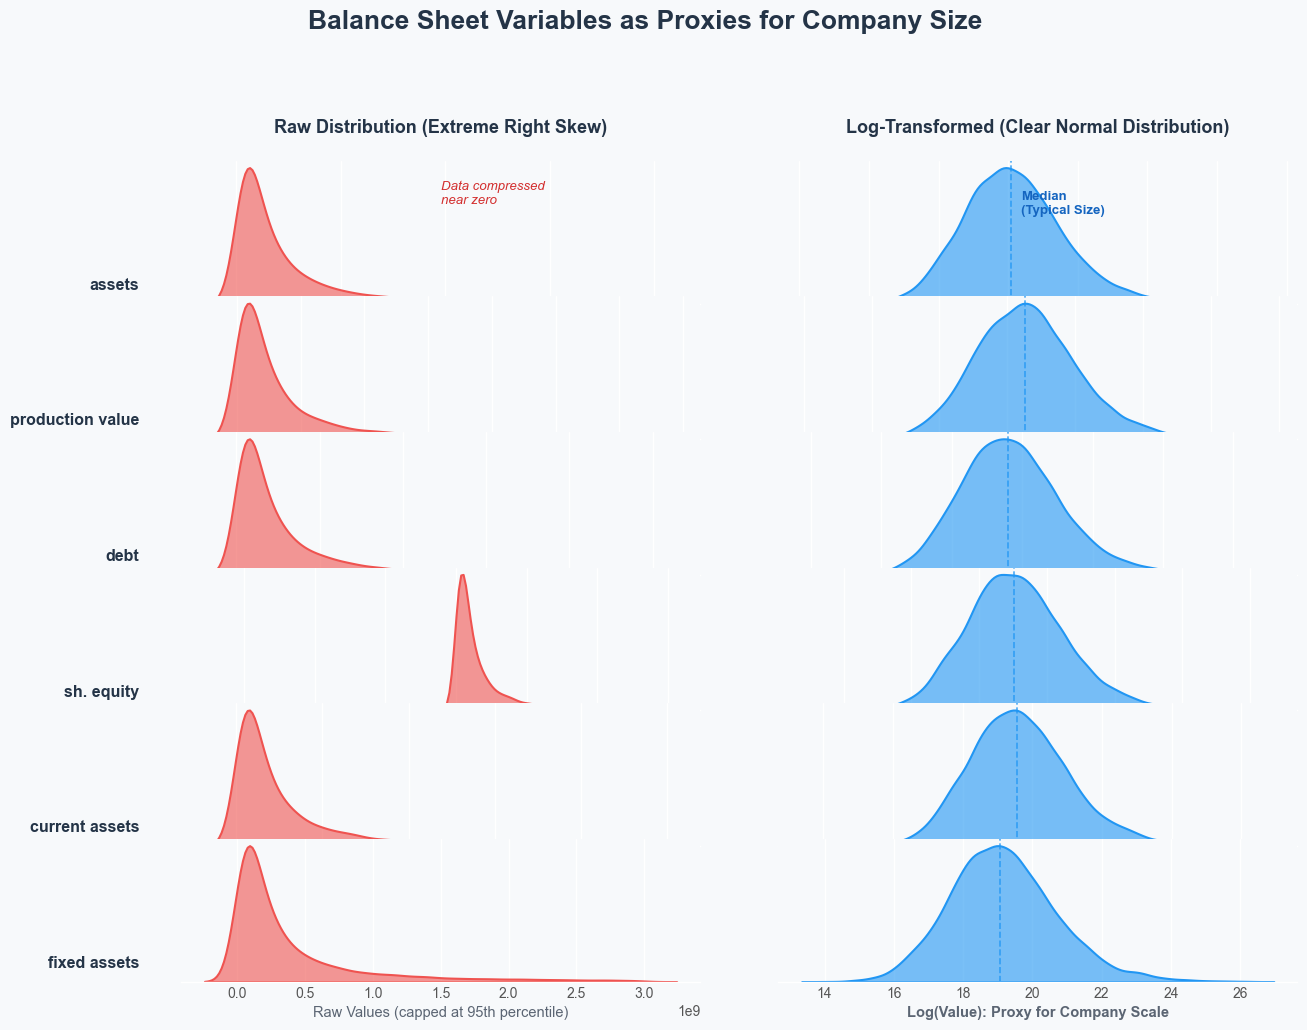

In [ ]:
short_lbls = [
    c.replace("total_", "")
     .replace("shareholders_", "sh. ")
     .replace("_", " ")
    for c in BS_COLS
]

# FIGURE 3: Balance Sheet Variables: Raw vs Log-Transformed
fig, axes = plt.subplots(
    len(BS_COLS), 2,
    figsize=(14.5, 1.8 * len(BS_COLS)),
    gridspec_kw={"hspace": -0.05}
)
fig.patch.set_facecolor(BG)

axes[0, 0].set_title("Raw Distribution (Extreme Right Skew)", fontsize=13,
                      fontweight="bold", color=TEXT, pad=20)
axes[0, 1].set_title("Log-Transformed (Clear Normal Distribution)", fontsize=13,
                      fontweight="bold", color=TEXT, pad=20)

for i, col in enumerate(BS_COLS):
    ax_raw = axes[i, 0]
    ax_log = axes[i, 1]
    ax_raw.set_facecolor(BG)
    ax_log.set_facecolor(BG)
    for ax in [ax_raw, ax_log]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.set_yticks([])
    vals = train_df[col].dropna()
    val_95 = vals.quantile(0.95)
    raw_plot_data = vals[vals < val_95]
    log_vals = np.log1p(vals[vals > 0])
    sns.kdeplot(raw_plot_data, ax=ax_raw, fill=True, color="#ef5350", alpha=0.6, linewidth=1.5)
    sns.kdeplot(log_vals, ax=ax_log, fill=True, color="#2196f3", alpha=0.6, linewidth=1.5)
    median_val = log_vals.median()
    ax_log.axvline(median_val, color="#2196f3", linestyle="--", linewidth=1.2, alpha=0.8)
    if i == 0:
        y_max = ax_log.get_ylim()[1]
        ax_log.text(median_val + 0.3, y_max * 0.7, "Median\n(Typical Size)",
                    color="#1565c0", fontsize=9.5, fontweight="bold", va="center")
        ax_raw.text(0.5, 0.7, "Data compressed\nnear zero",
                    transform=ax_raw.transAxes, color="#d32f2f", fontsize=9.5, style="italic")
    ax_raw.text(-0.08, 0.1, short_lbls[i], transform=ax_raw.transAxes,
                fontsize=11.5, fontweight="bold", color=TEXT, ha="right")
    if i < len(BS_COLS) - 1:
        ax_raw.set_xlabel("")
        ax_raw.set_xticklabels([])
        ax_log.set_xlabel("")
        ax_log.set_xticklabels([])
    else:
        ax_raw.set_xlabel("Raw Values (capped at 95th percentile)", fontsize=10.5, color=SUBTLE)
        ax_log.set_xlabel("Log(Value): Proxy for Company Scale", fontsize=10.5,
                          color=SUBTLE, fontweight="bold")

fig.suptitle("Balance Sheet Variables as Proxies for Company Size",
             fontsize=19, fontweight="bold", y=0.98, color=TEXT)
plt.subplots_adjust(top=0.84, bottom=0.08, left=0.18, right=0.95, wspace=0.15)
plt.savefig(FIG_DIR / "size_proxy_ridgeplot_v2.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

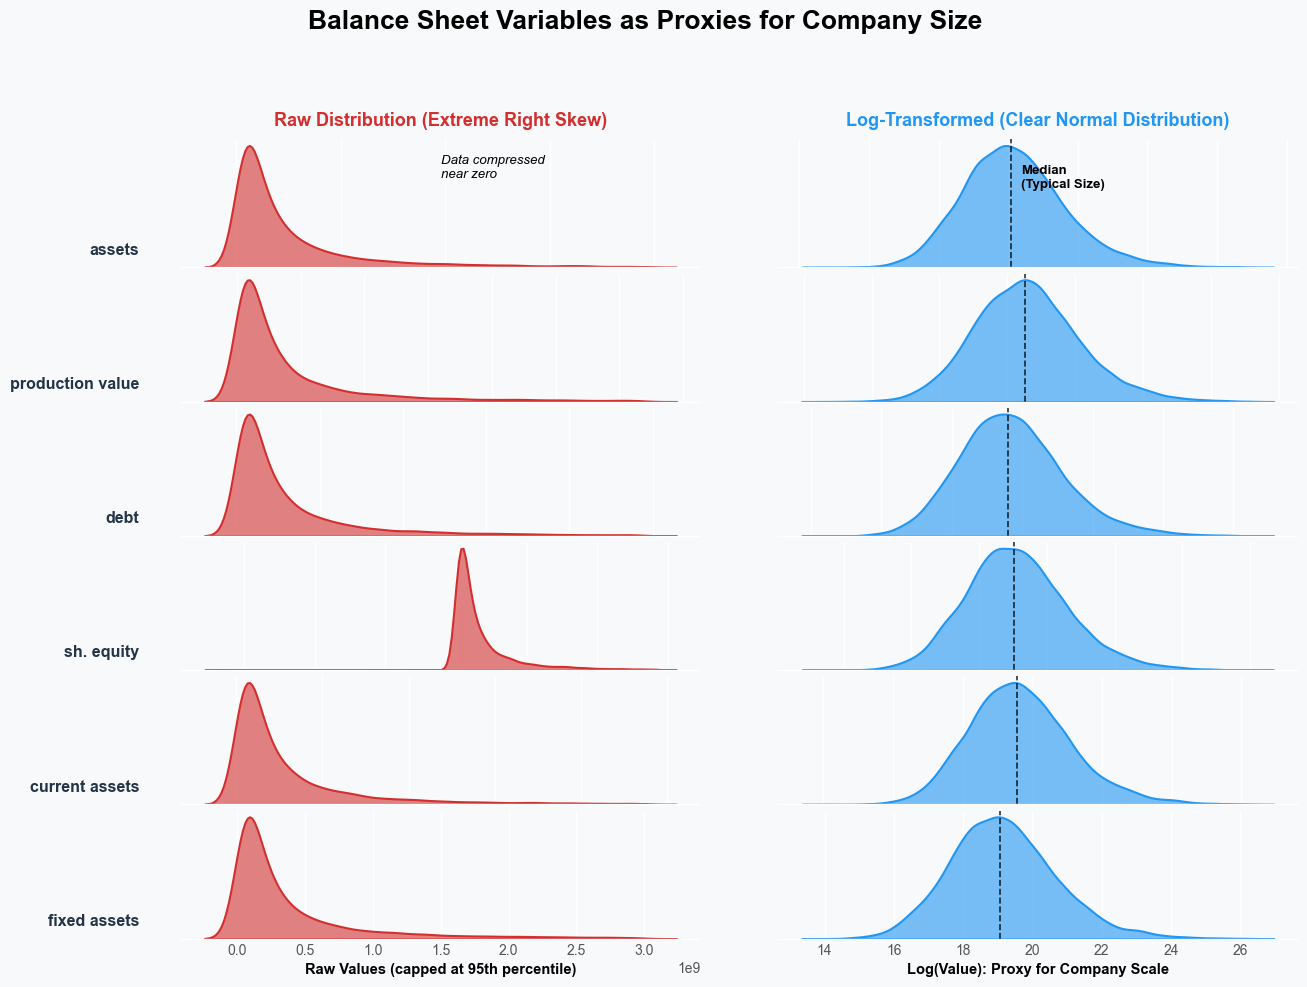

In [ ]:
short_lbls = [
    c.replace("total_", "")
     .replace("shareholders_", "sh. ")
     .replace("_", " ")
    for c in BS_COLS
]

fig, axes = plt.subplots(
    len(BS_COLS), 2,
    figsize=(14.5, 1.8 * len(BS_COLS)),
    gridspec_kw={"hspace": 0.05}
)
fig.patch.set_facecolor(BG)

axes[0, 0].set_title("Raw Distribution (Extreme Right Skew)", fontsize=13,
                      fontweight="bold", color="#d32f2f", pad=10)
axes[0, 1].set_title("Log-Transformed (Clear Normal Distribution)", fontsize=13,
                      fontweight="bold", color="#2196f3", pad=10)

for i, col in enumerate(BS_COLS):
    ax_raw = axes[i, 0]
    ax_log = axes[i, 1]
    ax_raw.set_facecolor(BG)
    ax_log.set_facecolor(BG)
    for ax in [ax_raw, ax_log]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.set_yticks([])
    vals = train_df[col].dropna()
    val_95 = vals.quantile(0.95)
    raw_plot_data = vals[vals < val_95]
    log_vals = np.log1p(vals[vals > 0])
    sns.kdeplot(raw_plot_data, ax=ax_raw, fill=True, color="#d32f2f", alpha=0.6, linewidth=1.5)
    sns.kdeplot(log_vals, ax=ax_log, fill=True, color="#2196f3", alpha=0.6, linewidth=1.5)
    median_val = log_vals.median()
    ax_log.axvline(median_val, color="#000000", linestyle="--", linewidth=1.2, alpha=0.8)
    if i == 0:
        y_max = ax_log.get_ylim()[1]
        ax_log.text(median_val + 0.3, y_max * 0.7, "Median\n(Typical Size)",
                    color="#000000", fontsize=9.5, fontweight="bold", va="center")
        ax_raw.text(0.5, 0.7, "Data compressed\nnear zero",
                    transform=ax_raw.transAxes, color="#000000", fontsize=9.5, style="italic")
    ax_raw.text(-0.08, 0.1, short_lbls[i], transform=ax_raw.transAxes,
                fontsize=11.5, fontweight="bold", color=TEXT, ha="right")
    if i < len(BS_COLS) - 1:
        ax_raw.set_xlabel("")
        ax_raw.set_xticklabels([])
        ax_log.set_xlabel("")
        ax_log.set_xticklabels([])
    else:
        ax_raw.set_xlabel("Raw Values (capped at 95th percentile)", fontsize=10.5,color="#000000", fontweight="bold")
        ax_log.set_xlabel("Log(Value): Proxy for Company Scale", fontsize=10.5,
                          color="#000000", fontweight="bold")

fig.suptitle("Balance Sheet Variables as Proxies for Company Size",
             fontsize=19, fontweight="bold", y= 0.94, color="#000000")

plt.subplots_adjust(top=0.82, bottom=0.08, left=0.18, right=0.95, wspace=0.15)
plt.savefig(FIG_DIR / "size_proxy_ridgeplot_v2.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

The distribution plots show that skewness is not a minor artifact but a **structural
property** of the dataset:

- **Balance-sheet and scale variables are heavily right-skewed**, with a long tail of
  much larger firms.
- The bulk of observations is compressed near the lower end of the range, while a small
  number of firms occupy the extreme upper tail.
- This pattern is economically plausible and expected in heterogeneous firm populations.

| Variable Type | Typical Shape | Modeling Implication |
|---------------|--------------|----------------------|
| **Size / balance-sheet totals** | Strong right skew | Log transforms or tree-based models |
| **Ratio variables** | Often more centered but still noisy | May still need robust scaling |
| **Mixed financial indicators** | Can contain both skewness and instability | Avoid assuming Gaussian behavior |

Heavy skew in financial data is not automatically a cleaning problem. In many cases, it reflects the real size distribution of firms rather than spurious observations.

### 5.4 Outlier Diagnostics

To assess whether extreme values are isolated anomalies or a persistent structural
feature, we inspect winsorized boxplots (1st–99th percentile). Winsorization is used
here **only for visualization**, so the central distribution remains readable without
letting a few extreme observations dominate the scale.

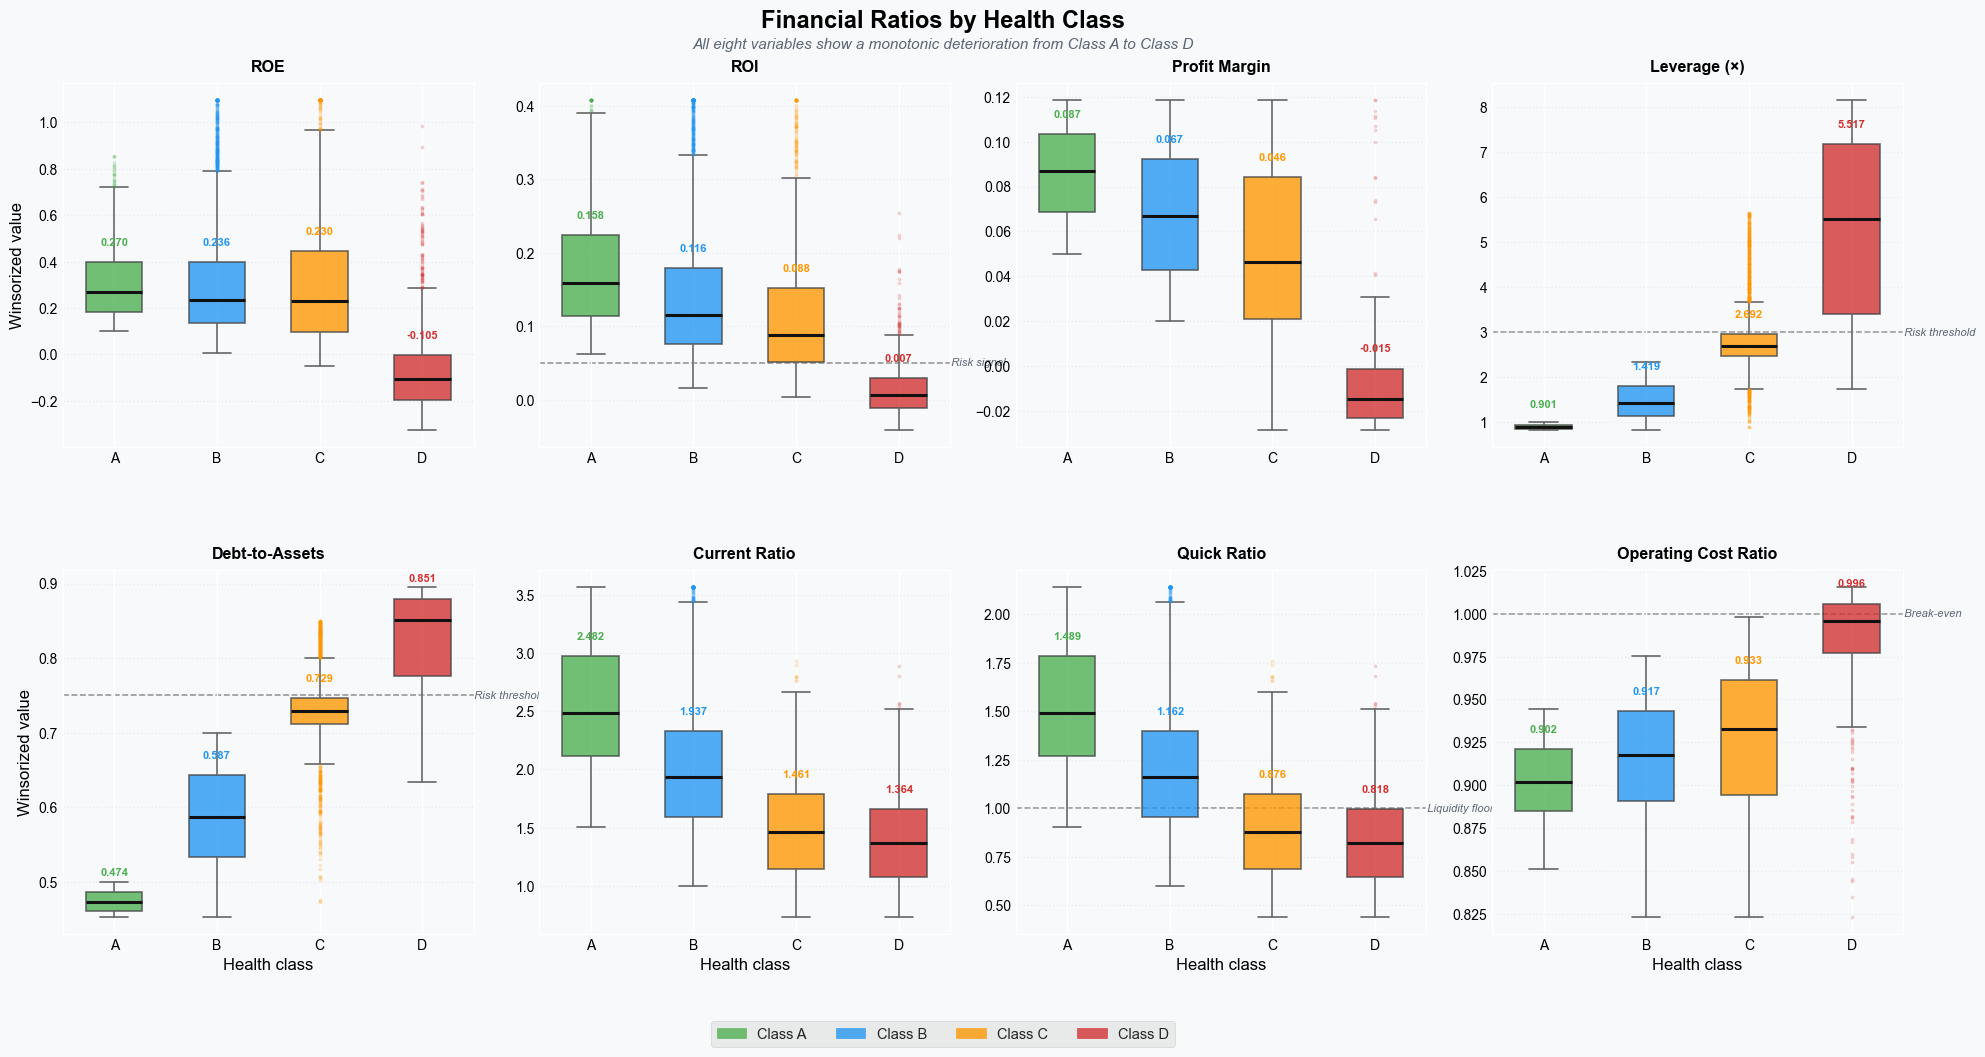

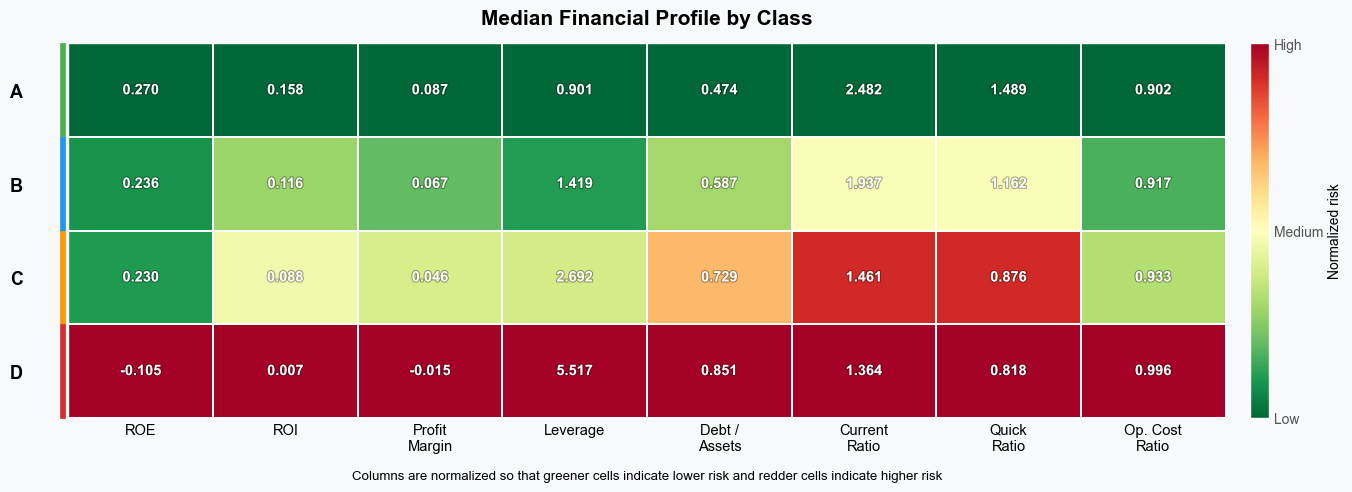

In [ ]:
# Prep: winsorized copy for visualization
ALL_COLS = RATIO_COLS + ["op_cost_ratio"]
kw_results["op_cost_ratio"] = p_op

plot_df = train_df.copy()
for col in ALL_COLS:
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

YLABELS = {
    "roe": "ROE", "roi": "ROI", "profit_margin": "Profit Margin",
    "leverage": "Leverage (×)", "debt_to_assets": "Debt-to-Assets",
    "current_ratio": "Current Ratio", "quick_ratio": "Quick Ratio",
    "op_cost_ratio": "Operating Cost Ratio",
}
THRESHOLDS = {
    "leverage": (3.0, "Risk threshold"), "debt_to_assets": (0.75, "Risk threshold"),
    "quick_ratio": (1.0, "Liquidity floor"), "op_cost_ratio": (1.0, "Break-even"),
    "roi": (0.05, "Risk signal"),
}
COL_LABELS = {
    "roe": "ROE", "roi": "ROI", "profit_margin": "Profit\nMargin",
    "leverage": "Leverage", "debt_to_assets": "Debt /\nAssets",
    "current_ratio": "Current\nRatio", "quick_ratio": "Quick\nRatio",
    "op_cost_ratio": "Op. Cost\nRatio",
}
FLIP_COLS = ["roe", "roi", "profit_margin", "current_ratio", "quick_ratio"]

# FIGURE 1: Financial Ratios by Health Class (boxplots)
fig, axes = plt.subplots(2, 4, figsize=(20, 10.5))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)
    data_by_class = [plot_df.loc[plot_df[TARGET] == c, col].dropna() for c in CLASSES]
    bp = ax.boxplot(
        data_by_class, patch_artist=True, widths=0.55,
        medianprops=dict(color="#111111", linewidth=2.2),
        whiskerprops=dict(linewidth=1.2, color="#666666"),
        capprops=dict(linewidth=1.2, color="#666666"),
        flierprops=dict(marker="o", markersize=1.8, alpha=0.15, linestyle="none"),
        boxprops=dict(linewidth=1.2, edgecolor="#444444"),
    )
    for patch, cls in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.78)
    for flier, cls in zip(bp["fliers"], CLASSES):
        flier.set_markerfacecolor(palette[cls])
        flier.set_markeredgecolor(palette[cls])
    if col in THRESHOLDS:
        val, label = THRESHOLDS[col]
        ax.axhline(val, color="#7a7a7a", linestyle="--", linewidth=1.15, alpha=0.8, zorder=0)
        ax.text(4.45, val, f"  {label}", va="center", ha="left",
                fontsize=8, color=SUBTLE, style="italic")
    y_min, y_max = ax.get_ylim()
    
    for j, (d, cls) in enumerate(zip(data_by_class, CLASSES), start=1):
        q3 = np.percentile(d, 75)
        ax.text(j, q3 + (y_max - y_min) * 0.04, f"{d.median():.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold", color=palette[cls])
        
    ax.set_title(f"{YLABELS[col]}", fontsize=11.5, pad=8, color="#000000")  # ← stars removed, black
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(CLASSES, color="#000000")  # ← black
    ax.grid(axis="y", linestyle=":", alpha=0.45, color=GRID)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", colors="#000000")  # ← black
    ax.set_ylabel("Winsorized value" if i % 4 == 0 else "", color="#000000")  # ← black
    ax.set_xlabel("Health class" if i >= 4 else "", color="#000000")  # ← black

legend_patches = [mpatches.Patch(color=palette[c], alpha=0.78, label=f"Class {c}") for c in CLASSES]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, fontsize=10.5,
           frameon=True, bbox_to_anchor=(0.5, -0.005))
fig.suptitle("Financial Ratios by Health Class", fontsize=17, fontweight="bold", y=0.99, color="#000000")  # ← black
fig.text(0.5, 0.953, "All eight variables show a monotonic deterioration from Class A to Class D",
         ha="center", fontsize=11, color=SUBTLE, style="italic")

plt.subplots_adjust(top=0.92, bottom=0.11, left=0.06, right=0.98, hspace=0.34, wspace=0.16)
plt.savefig(FIG_DIR / "ratio_boxplots_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# FIGURE 2: Median Financial Profile by Class (heatmap)
median_table = pd.DataFrame(
    {col: [plot_df.loc[plot_df[TARGET] == c, col].median() for c in CLASSES] for col in ALL_COLS},
    index=CLASSES
)
normed = median_table.copy()
for col in normed.columns:
    lo, hi = normed[col].min(), normed[col].max()
    normed[col] = (normed[col] - lo) / (hi - lo + 1e-9)
for col in FLIP_COLS:
    normed[col] = 1 - normed[col]

fig, ax = plt.subplots(figsize=(14.5, 5.2))
fig.patch.set_facecolor(BG)

ax.set_facecolor(BG)
X = np.arange(len(ALL_COLS) + 1)
Y = np.arange(len(CLASSES) + 1)
mesh = ax.pcolormesh(X, Y, normed.values, cmap=plt.cm.RdYlGn_r, vmin=0, vmax=1,
                     edgecolors="white", linewidth=1.2, shading="flat")
ax.invert_yaxis()
for i, cls in enumerate(CLASSES):
    for j, col in enumerate(ALL_COLS):
        raw = median_table.loc[cls, col]
        t = ax.text(j + 0.5, i + 0.5, f"{raw:.3f}", ha="center", va="center",
                    fontsize=10.5, fontweight="bold", color="white")
        t.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black", alpha=0.35)])

for i, cls in enumerate(CLASSES):
    ax.add_patch(plt.Rectangle((-0.06, i), 0.035, 1, color=palette[cls],
                                transform=ax.transData, clip_on=False, zorder=5))


ax.set_xticks(np.arange(len(ALL_COLS)) + 0.5)
ax.set_xticklabels([COL_LABELS[c] for c in ALL_COLS], fontsize=10.5, color="#000000")  # ← black
ax.set_yticks(np.arange(len(CLASSES)) + 0.5)
ax.set_yticklabels(CLASSES, fontsize=13, fontweight="bold", color="#000000", x=-0.035)  # ← black
ax.tick_params(length=0)

cbar = plt.colorbar(mesh, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Normalized risk", fontsize=10, color="#000000")  # ← black
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Medium", "High"])

ax.set_title("Median Financial Profile by Class", fontsize=15, fontweight="bold", pad=14, color="#000000")  # ← black
ax.set_xlabel("Columns are normalized so that greener cells indicate lower risk and redder cells indicate higher risk",
              fontsize=9.5, color="#000000", labelpad=12)  # ← black


plt.subplots_adjust(top=0.94, bottom=0.22, left=0.12, right=0.96)
plt.savefig(FIG_DIR / "ordinal_gradient_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

### 5.5 Interpretation

The boxplots confirm that extreme values are **persistent**, not incidental:

- Even after **1–99% winsorization**, many variables still retain wide spreads and long whiskers: the dataset is **structurally heavy-tailed**.
- Large dispersion is part of the economic reality of the sample, not a data-entry problem.
- The heatmap confirms a **clean monotonic gradient** from Class A to Class D across all eight ratio features, with no exceptions.

**Modeling implication**

- Avoid indiscriminate row deletion based on standard outlier rules.
- Prefer **robust scaling**, **log transforms for strictly positive size variables**, and model families that tolerate non-Gaussian inputs well.
- Tree-based learners are naturally well-suited to this structure, while linear models will require more careful preprocessing.

### 5.6 Threshold Audit

We use a shallow decision tree (depth = 2) on each feature independently to automatically recover the most discriminative thresholds in the training set. 
The objective is to identify whether any single rule cleanly separates one class, and to decide which boolean flags are worth engineering explicitly.

In [ ]:
def extract_optimal_thresholds(df, features, target, max_depth=2):
    optimal_rules = []
    le = LabelEncoder()
    y = le.fit_transform(df[target])

    for col in features:
        df_sub = df[[col, target]].dropna()
        X_col = df_sub[[col]].values
        y_col = le.transform(df_sub[target])
        if len(df_sub) < 50:
            continue
        tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=0.05)
        tree.fit(X_col, y_col)
        thresholds = [t for t in tree.tree_.threshold if t != -2]
        for t in thresholds:
            for direction in ["below", "above"]:
                mask = df_sub[col] < t if direction == "below" else df_sub[col] > t
                n_cases = mask.sum()
                if n_cases < 50:
                    continue
                dist = df_sub[mask][target].value_counts(normalize=True).mul(100)
                dom_class = dist.idxmax()
                dom_pct = dist.max()
                optimal_rules.append({
                    "feature": col,
                    "threshold": round(t, 4),
                    "direction": direction,
                    "n": n_cases,
                    "dominant_class": dom_class,
                    "precision": round(dom_pct, 2),
                    "rule_string": f"{col} {'<' if direction == 'below' else '>'} {round(t, 4)}"
                })

    return pd.DataFrame(optimal_rules).sort_values(by=["precision", "n"], ascending=False)


features_to_audit = ["roe", "roi", "current_ratio", "debt_to_assets", "leverage", "profit_margin"]
dynamic_audit_df = extract_optimal_thresholds(train_df, features_to_audit, TARGET)

print("AUTO-GENERATED THRESHOLDS (top precision)")
print(dynamic_audit_df[dynamic_audit_df["precision"] > 80].head(10))

AUTO-GENERATED THRESHOLDS (top precision)
           feature  threshold direction     n dominant_class  precision  \
0              roe    -0.0499     below   708              D     100.00   
19  debt_to_assets     0.8443     above   592              D      95.10   
28   profit_margin    -0.0051     below   825              D      90.79   
25        leverage     5.2147     above   590              D      90.51   
14  debt_to_assets     0.6999     below  8260              B      84.95   
20        leverage     2.3331     below  8260              B      84.95   
4              roi     0.0220     below   876              D      84.70   

                rule_string  
0             roe < -0.0499  
19  debt_to_assets > 0.8443  
28  profit_margin < -0.0051  
25        leverage > 5.2147  
14  debt_to_assets < 0.6999  
20        leverage < 2.3331  
4               roi < 0.022  


**Key findings from the audit:**

- **Class D — deterministic signal**: `equity ≤ 0` and `DTA ≥ 1` capture the same 45 rows (accounting identity). `roe < −0.05` is the single most powerful rule: 708 cases, 67% of all Class D, 100% precision.
- **Class B — single rule dominance**: `debt_to_assets < 0.7` appears as the best split on two consecutive boundaries (A↔B and B↔C).
- **Class C — no positive rules**: no single threshold identifies Class C above 60% precision. Class C is defined by exclusion — not healthy enough for B, not distressed enough for D.
- **Class A — combination-dependent**: requires feature interactions (high ROE + low DTA + positive margins). Do not engineer a single `is_likely_A` flag.

Validate `roe_below_005`, `dta_above_085`, `dta_below_070` on the 2021 holdout before final inclusion.

## Section 5: Findings
### Numerical Feature Behavior: Summary

The numerical feature space shows a classic firm-level financial-data pattern: **large scale heterogeneity, strong right skew in size variables, and persistent heavy tails even after mild winsorization**.

| Diagnostic | Main Result | Interpretation |
|------------|-------------|----------------|
| **Summary statistics** | Very large gaps between medians and maxima | Several variables are strongly right-skewed |
| **Distribution plots** | Mass concentrated near lower ranges with long upper tails | Firm size is highly heterogeneous |
| **Winsorized boxplots** | Wide spreads remain after 1–99% trimming | Extreme values are structural, not isolated noise |
| **Threshold audit** | Class D has 8 rules at 100% precision; Class A has zero | Task is asymmetric — extremes are deterministic, center is soft |


### What This Means for Modeling

The descriptive analysis supports the following preprocessing logic:

1. **Do not assume Gaussian structure**: raw numerical variables are not naturally symmetric or homoscedastic.
2. **Treat outliers as economically meaningful unless proven otherwise**: extreme values in accounting data reflect genuine firm heterogeneity.
3. **Use log transforms selectively**: apply only to strictly positive scale variables where compression demonstrably improves separability.
4. **Prefer robust preprocessing for linear models**: robust scaling is more defensible than standard scaling under heavy tails.
5. **Expect tree-based models to be naturally advantaged**: the distributional structure is well aligned with non-linear, threshold-based learners.


### Preprocessing Decisions from Section 5

| Decision | Rationale |
|----------|-----------|
| Log-transform balance-sheet size variables | Raw skew ~19; log skew ~0.4 — compression is dramatic and justified |
| Do **not** log-transform ratio variables | Ratios can be negative or near-zero; log is numerically unstable |
| Apply robust scaling for linear models | Heavy tails make mean/std unreliable anchors |
| Do **not** delete rows based on outlier rules | Extreme values reflect structural firm heterogeneity |
| Engineer `roe_below_005`, `dta_above_085`, `dta_below_070` boolean flags | 100% precision on Class D in training set |
| Do **not** engineer a single `is_likely_A` flag | Class A requires feature interactions — a single flag would be noisy |
| Validate all boolean flags on 2021 holdout before final inclusion | Flags derived from training thresholds risk overfitting the training distribution |
| Prefer tree-based models as baseline | Naturally robust to skew, scale, and threshold-style boundaries |

The dataset is **numerically complex but not numerically broken**. The correct response is **economically aware preprocessing**, not aggressive sanitization.

## 6. Correlation & Feature Relevance Analysis
Correlation analysis is used here to distinguish **economically expected relationships** from **true redundancy**. In financial datasets, many variables move together because of accounting identities, shared denominators, or firm-size effects — so high correlation is not automatically a problem. The objective is not to drop correlated features mechanically, but to identify where correlation reflects duplicated information versus where it preserves distinct financial meaning.

### 6.1 Diagnostic Scope

This section focuses on three questions:

1. **How structured is the global dependence pattern** among numerical variables?
2. **Which relationships are strong enough to deserve explicit review?**
3. **Which correlations imply redundancy**, and which should be retained because they still represent different economic mechanisms?

### 6.2 Mutual Information: Raw vs. Sector-Normalized Features

We compute Mutual Information (MI) scores for each feature in two versions: the raw feature value, and a sector-normalized delta (value minus sector median). The objective is to assess whether adjusting for sector context improves or degrades the predictive signal of each variable.

In [ ]:
df = train_df.copy()
TARGET = "financial_health_class"

exclude_cols = [
    "company_id", "fiscal_year", "ateco_sector", "province", "region", "legal_form",
    "bankruptcy_next_year", "financial_health_class", "revenue_change"
]

features_base = [
    col for col in df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
]

print(f"Analyzing {len(features_base)} numeric features\n")

df_clean = df.dropna(subset=["ateco_sector", TARGET]).copy()

imputer = SimpleImputer(strategy="median")
df_clean[features_base] = imputer.fit_transform(df_clean[features_base])

features_delta = []
for f in features_base:
    sector_mean = df_clean.groupby("ateco_sector")[f].transform("mean")
    delta_col = f"{f}_delta"
    df_clean[delta_col] = (df_clean[f] - sector_mean).fillna(0)
    features_delta.append(delta_col)

X = df_clean[features_base + features_delta]
y = df_clean[TARGET].astype("category").cat.codes

mi_scores = mutual_info_classif(X, y, random_state=42)

results = []
for i, f in enumerate(features_base):
    score_raw   = mi_scores[i]
    score_delta = mi_scores[len(features_base) + i]
    winner      = "Raw" if score_raw >= score_delta else "Delta"
    diff_pct    = ((score_delta - score_raw) / score_raw * 100) if score_raw > 0 else 0
    results.append({
        "Feature":      f,
        "Raw Score":    score_raw,
        "Delta Score":  score_delta,
        "Winner":       winner,
        "% Change":     diff_pct,
    })

df_results = pd.DataFrame(results).sort_values("Raw Score", ascending=False)
df_results["Raw Score"]   = df_results["Raw Score"].apply(lambda x: "0" if round(x, 4) == 0 else f"{x:.4f}")
df_results["Delta Score"] = df_results["Delta Score"].apply(lambda x: "0" if round(x, 4) == 0 else f"{x:.4f}")
df_results["% Change"]    = df_results["% Change"].apply(lambda x: f"{x:+.1f}%")

print("MUTUAL INFORMATION RESULTS (Task 2: Financial Health)\n")
print(df_results.to_markdown(index=False, colalign=("left", "right", "right", "left", "right")))

Analyzing 23 numeric features

MUTUAL INFORMATION RESULTS (Task 2: Financial Health)

| Feature              |   Raw Score |   Delta Score | Winner   |   % Change |
|:---------------------|------------:|--------------:|:---------|-----------:|
| debt_to_assets       |      0.7912 |        0.7692 | Raw      |      -2.8% |
| leverage             |      0.7894 |        0.7325 | Raw      |      -7.2% |
| profit_margin        |      0.3292 |        0.3208 | Raw      |      -2.6% |
| op_cost_ratio        |       0.262 |        0.2481 | Raw      |      -5.3% |
| roe                  |       0.245 |        0.1857 | Raw      |     -24.2% |
| roi                  |      0.2401 |        0.1843 | Raw      |     -23.3% |
| net_profit_loss      |      0.2165 |        0.0855 | Raw      |     -60.5% |
| current_ratio        |      0.1937 |        0.2245 | Delta    |     +15.9% |
| quick_ratio          |       0.191 |        0.2255 | Delta    |     +18.1% |
| operating_income     |      0.1305 |       

### 6.3 ATECO Sector: Class Distribution

In [ ]:
TARGET = "financial_health_class"
YEAR_COL = "fiscal_year"

ateco_map = {
    (10, 33): "Manufacturing",
    (41, 43): "Construction",
    (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food",
    (58, 63): "Info & Communication",
    (68, 68): "Real Estate",
    (69, 75): "Prof. & Scientific",
    (77, 82): "Admin & Support",
}

def get_sector_name(code):
    try:
        c = int(code)
        for (lo, hi), name in ateco_map.items():
            if lo <= c <= hi:
                return name
    except:
        pass
    return "Other"

df = train_df.copy()
df["sector_name"] = (
    df["ateco_sector"].astype(str).str.zfill(2).apply(get_sector_name)
)


CLASS_ORDER = ["A", "B", "C", "D"]
CLASS_COLORS = {
    "A": "#4CAF50",   # green
    "B": "#2196F3",   # blue
    "C": "#FF9800",   # orange
    "D": "#D32F2F"    # red
}

dist = (
    df.groupby(["sector_name", TARGET])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=CLASS_ORDER, fill_value=0)
)

dist_pct = dist.div(dist.sum(axis=1), axis=0).mul(100)


sector_order = [
    "Real Estate",
    "Info & Communication",
    "Prof. & Scientific",
    "Manufacturing",
    "Wholesale & Retail",
    "Admin & Support",
    "Accommodation & Food",
    "Construction"
]

dist_pct = dist_pct.reindex([s for s in sector_order if s in dist_pct.index])

global_d = df[TARGET].value_counts(normalize=True).get("D", 0) * 100


fig1 = go.Figure()

for cls in CLASS_ORDER:
    fig1.add_trace(
        go.Bar(
            name=f"Class {cls}",
            x=dist_pct[cls],
            y=dist_pct.index.tolist(),
            orientation="h",
            marker=dict(color=CLASS_COLORS[cls], line=dict(width=0)),
            hovertemplate=f"Class {cls}: %{{x:.1f}}%<extra></extra>"
        )
    )

# baseline D
fig1.add_vline(
    x=global_d,
    line=dict(color="#d32f2f", width=1.5, dash="dot")
)

fig1.add_annotation(
    x=global_d,
    y=-0.7,
    xref="x",
    yref="y",
    text=f"<i>D baseline {global_d:.1f}%</i>",
    showarrow=False,
    font=dict(size=13, color="#d32f2f"),
    xanchor="left"
)

fig1.update_layout(
    title=dict(
        text=(
            "<b>ATECO Sector: Class Distribution</b>"
            "<br><span style='font-size:11px; font-weight:normal; color:#777777;'>"
            "D-rate spread across sectors → weak standalone signal"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        y=0.95,
        font=dict(size=18, color="#222222")
    ),
    barmode="stack",
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial", size=12, color="#333333"),
    width=1050,
    height=520,
    margin=dict(t=90, l=170, r=40, b=80),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.12,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(0,0,0,0)",
        traceorder="normal"
    ),
    xaxis=dict(
        title="Share (%)",
        range=[0, 100],
        dtick=20,
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="",
        showgrid=False,
        autorange="reversed"
    )
)

fig1.show()

### 6.4 Sector Normalization: Information Gain Shift (ΔMI)

For each feature we compare MI in its raw form against a sector-adjusted version (value minus sector median). 

A **positive ΔMI** means normalization helps; a negative ΔMI means the sector adjustment destroys signal that was already present in the raw value.

In [ ]:
TARGET  = "financial_health_class"
N_BOOT  = 30

CAT_MAP = {
    "roe": "PROFITABILITY", "roi": "PROFITABILITY",
    "profit_margin": "PROFITABILITY", "debt_to_assets": "SOLVENCY",
    "current_ratio": "LIQUIDITY", "log_total_assets": "SIZE",
    "years_in_business": "AGE",
}
DISPLAY_NAME_MAP = {
    "current_ratio": "CURRENT_RATIO", "years_in_business": "YEARS_IN_BUSINESS",
    "log_total_assets": "LOG_TOTAL_ASSETS", "profit_margin": "PROFIT_MARGIN",
    "debt_to_assets": "DEBT_TO_ASSETS", "roi": "ROI", "roe": "ROE",
}
NATIVE  = ["roe", "roi", "debt_to_assets", "profit_margin", "current_ratio", "years_in_business"]
DERIVED = {"log_total_assets": lambda df: np.log1p(df["total_assets"])}
ALL_FEATURES         = NATIVE + list(DERIVED.keys())
RAW_COLS_FOR_DERIVED = ["production_costs", "production_value", "total_assets"]

load_cols = list(dict.fromkeys(NATIVE + RAW_COLS_FOR_DERIVED + ["sector_name", TARGET]))
df_mi = (
    train_df[load_cols]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
    .reset_index(drop=True)
)
for col, fn in DERIVED.items():
    df_mi[col] = fn(df_mi)
df_mi = df_mi[ALL_FEATURES + ["sector_name", TARGET]].dropna().reset_index(drop=True)
y     = df_mi[TARGET].astype("category").cat.codes

sector_medians = df_mi.groupby("sector_name")[ALL_FEATURES].median()
for col in ALL_FEATURES:
    df_mi[f"{col}_vs_sector"] = (
        df_mi[col] - df_mi["sector_name"].map(sector_medians[col])
    )

rng = np.random.default_rng(42)
mi_results = []
for col in ALL_FEATURES:
    rel_col = f"{col}_vs_sector"
    mi_raw  = mutual_info_classif(df_mi[[col]], y, random_state=42)[0]
    mi_rel  = mutual_info_classif(df_mi[[rel_col]], y, random_state=42)[0]
    delta   = mi_rel - mi_raw
    pct     = (delta / mi_raw * 100) if mi_raw > 0 else 0.0
    boot_deltas = []
    for _ in range(N_BOOT):
        idx  = rng.choice(len(df_mi), size=len(df_mi), replace=True)
        y_b  = y.iloc[idx].reset_index(drop=True)
        sub  = df_mi.iloc[idx].reset_index(drop=True)
        seed = int(rng.integers(0, 1_000_000))
        mi_r_b = mutual_info_classif(sub[[col]], y_b, random_state=seed)[0]
        mi_a_b = mutual_info_classif(sub[[rel_col]], y_b, random_state=seed)[0]
        boot_deltas.append(mi_a_b - mi_r_b)
    ci_low, ci_high = np.percentile(boot_deltas, 5), np.percentile(boot_deltas, 95)
    mi_results.append({
        "col": col,
        "display_name": DISPLAY_NAME_MAP.get(col, col.upper()),
        "category": CAT_MAP.get(col, "OTHER"),
        "mi_raw": mi_raw, "delta": delta, "pct": pct,
        "ci_low": ci_low, "ci_high": ci_high,
        "ci_crosses_zero": ci_low < 0 < ci_high,
    })

mi_results.sort(key=lambda x: x["delta"], reverse=True)
n      = len(mi_results)
y_pos  = list(range(n))
deltas = [d["delta"] for d in mi_results]

def get_bar_color(v):
    if v >= 0:        return "#A8C5AE"
    elif v >= -0.015: return "#F2B8B1"
    elif v >= -0.040: return "#C93A2B"
    else:             return "#8E261A"

bar_colors    = [get_bar_color(d["delta"]) for d in mi_results]
bar_opacities = [0.45 if d["ci_crosses_zero"] else 1.0 for d in mi_results]
err_plus      = [abs(d["ci_high"] - d["delta"]) for d in mi_results]
err_minus     = [abs(d["delta"]   - d["ci_low"]) for d in mi_results]

x_min = min([d["ci_low"]  for d in mi_results] + deltas)
x_max = max([d["ci_high"] for d in mi_results] + deltas)
span  = x_max - x_min
x_min_plot = min(-0.10, x_min - span * 0.20)
x_max_plot = max(0.07,  x_max + span * 0.22)

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=deltas,
    y=y_pos,
    orientation="h",
    marker=dict(color=bar_colors, opacity=bar_opacities, line=dict(width=0)),
    error_x=dict(
        type="data", symmetric=False,
        array=err_plus, arrayminus=err_minus,
        color="#BDBDBD", thickness=1.4, width=3
    ),
    hovertemplate="<b>%{customdata}</b><br>ΔMI = %{x:.4f}<extra></extra>",
    customdata=[d["display_name"] for d in mi_results],
    cliponaxis=False
))

fig1.add_vline(x=0, line=dict(color="#7F8C8D", width=2))
fig1.add_vline(x=x_min_plot + 0.001, line=dict(color="#C7C7C7", width=2))

label_x_map = {
    "current_ratio":    0.022,  "years_in_business": 0.015,
    "log_total_assets": -0.026, "profit_margin":     -0.030,
    "debt_to_assets":   -0.045, "roi":               -0.066,
    "roe":              -0.078,
}

for yi, d in zip(y_pos, mi_results):
    fig1.add_annotation(
        x=x_min_plot + 0.002, y=yi,
        xref="x", yref="y",
        text=(
            f"<b>{d['display_name']}</b>"
            f"<br><span style='font-size:9px; color:#6E6E6E;'>{d['category']}</span>"
        ),
        showarrow=False, xanchor="right", align="right", xshift=-12,
        font=dict(size=10, color="#2B2B2B", family="Arial")
    )

for yi, d in zip(y_pos, mi_results):
    if d["delta"] >= 0:
        x_txt    = label_x_map.get(d["col"], d["ci_high"] + 0.002)
        xanchor  = "left"
        color    = "#2E8B57"
    else:
        x_txt    = label_x_map.get(d["col"], d["delta"] - 0.010)
        xanchor  = "right"
        color    = "#C93A2B"
    fig1.add_annotation(
        x=x_txt, y=yi, xref="x", yref="y",
        text=f"<b>{d['delta']:+.4f} ({d['pct']:+.1f}%)</b>",
        showarrow=False, xanchor=xanchor, yanchor="middle",
        font=dict(size=11, color=color, family="Arial")
    )

fig1.add_annotation(
    x=0.04, y=1.08, xref="x", yref="paper",
    text="<b>NORMALIZATION HELPS →</b><br><span style='font-size:9px'>(Sector-adjusted is better)</span>",
    showarrow=False, font=dict(size=10, color="#2E8B57", family="Arial"), align="center"
)

fig1.update_layout(
    paper_bgcolor="white", plot_bgcolor="white",
    font=dict(family="Arial", size=11, color="#222222"),
    width=1120, height=560, bargap=0.34, showlegend=False,
    margin=dict(t=120, l=220, r=75, b=70),
    title=dict(
        text=(
            "<b>Does Sector Normalization Improve Predictive Power?</b>"
            "<br><span style='font-size:11px; color:#7A7A7A;'>"
            "ΔMI = Information Gain Shift · Whiskers: 90% Bootstrap Confidence Interval"
            "</span>"
        ),
        x=0.5, xanchor="center", y=0.965,
        font=dict(size=19, color="#222222", family="Arial")
    ),
    xaxis=dict(
        title="<b>ΔMI (Information Gain Shift)</b>",
        range=[x_min_plot, x_max_plot],
        showgrid=True, gridcolor="#E8E8E8", gridwidth=1,
        zeroline=False, tickfont=dict(size=10), title_font=dict(size=12)
    ),
    yaxis=dict(
        range=[-0.5, n - 0.5], showgrid=False,
        showticklabels=False, zeroline=False, autorange="reversed"
    )
)

fig1.show()

### 6.5 Credit Migration Matrix

We construct a year-over-year transition matrix to assess the **temporal stability** of health class assignments. High off-diagonal probability towards Class D indicates that firm deterioration is gradual and measurable supporting the case for temporal feature engineering. 

The `EXIT` column captures firms that leave the panel without a Class D label.

In [ ]:
df_sorted = (
    train_df[["company_id", "fiscal_year", TARGET]]
    .sort_values(["company_id", "fiscal_year"])
    .copy()
)
df_sorted["class_next"] = df_sorted.groupby("company_id")[TARGET].shift(-1)
last_year_per_company   = df_sorted.groupby("company_id")["fiscal_year"].transform("max")

df_sorted["class_next"] = df_sorted["class_next"].where(
    df_sorted["class_next"].notna(),
    other=np.where(
        last_year_per_company < df_sorted["fiscal_year"].max(),
        "EXIT", "TRAIN_END"
    )
)

df_trans     = df_sorted[df_sorted["class_next"] != "TRAIN_END"].copy()
trans_counts = df_trans.groupby([TARGET, "class_next"]).size().unstack(fill_value=0)
col_order    = [c for c in ["A", "B", "C", "D", "EXIT"] if c in trans_counts.columns]
row_order    = [c for c in ["A", "B", "C", "D"]         if c in trans_counts.index]
trans_counts = trans_counts.reindex(index=row_order, columns=col_order, fill_value=0)
trans_pct    = trans_counts.div(trans_counts.sum(axis=1), axis=0) * 100

rank         = {"A": 0, "B": 1, "C": 2, "D": 3, "EXIT": 4}
classes_from = trans_pct.index.tolist()
classes_to   = trans_pct.columns.tolist()
matrix       = trans_pct.values

cell_colors      = []
cell_font_colors = []

for r, cf in enumerate(classes_from):
    row_colors = []
    row_fonts  = []
    for c, ct in enumerate(classes_to):
        val = matrix[r, c]
        fr  = rank[cf]
        tr  = rank[ct]

        if ct == "EXIT":
            intensity = min(val / 10.0, 1.0)
            if val == 0.0:
                row_colors.append("rgba(240,240,240,0.5)")
                row_fonts.append("#999999")
            else:
                row_colors.append(f"rgba(211,47,47,{0.4 + 0.6*intensity:.2f})")
                row_fonts.append("white")
        elif fr == tr:
            intensity = min(val / 65.0, 1.0)
            row_colors.append(f"rgba(120,130,140,{0.15 + 0.55*intensity:.2f})")
            row_fonts.append("white" if val > 30 else "#000000")
        elif tr > fr:
            jump      = tr - fr
            intensity = min((val / 30.0) * (jump / 3.0), 1.0)
            row_colors.append(f"rgba(211,47,47,{0.12 + 0.65*intensity:.2f})")
            row_fonts.append("white" if intensity > 0.5 else "#000000")
        else:
            jump      = fr - tr
            intensity = min((val / 65.0) * (jump / 3.0), 1.0)
            row_colors.append(f"rgba(76,175,80,{0.12 + 0.65*intensity:.2f})")
            row_fonts.append("white" if intensity > 0.5 else "#000000")

    cell_colors.append(row_colors)
    cell_font_colors.append(row_fonts)

cell_texts = []
for r, cf in enumerate(classes_from):
    row_texts = []
    for c, ct in enumerate(classes_to):
        val = matrix[r, c]
        if val == 0.0:
            row_texts.append("<b>—</b>")
        elif ct == "EXIT":
            row_texts.append(f"<b>{val:.1f}%</b>")
        else:
            row_texts.append(f"{val:.1f}%")
    cell_texts.append(row_texts)

row_headers     = [f"<b>From {c}</b>" for c in classes_from]
col_headers     = ["<b>Year t</b>"] + [f"<b>→ {ct}</b>" for ct in classes_to]
col_widths      = [90] + [75] * (len(classes_to) - 1) + [60]

col_vals        = [[rh for rh in row_headers]]
col_fills       = [["#F0F0F0"] * len(classes_from)]
col_font_colors_table = [["#000000"] * len(classes_from)]

for c, ct in enumerate(classes_to):
    col_vals.append([cell_texts[r][c]       for r in range(len(classes_from))])
    col_fills.append([cell_colors[r][c]     for r in range(len(classes_from))])
    col_font_colors_table.append([cell_font_colors[r][c] for r in range(len(classes_from))])

n_trans = len(df_trans)
n_exits = int((df_trans["class_next"] == "EXIT").sum())

fig2 = go.Figure(data=[go.Table(
    columnwidth=col_widths,
    header=dict(
        values=col_headers,
        fill_color=["#E8E8E8"] * (1 + len(classes_to)),
        font=dict(color="#000000", size=12, family="Arial"),
        align="center", height=36, line_color="#CCCCCC",
    ),
    cells=dict(
        values=col_vals,
        fill_color=col_fills,
        font=dict(color=col_font_colors_table, size=12.5, family="Arial"),
        align="center", height=38, line_color="#E0E0E0",
    ),
)])

fig2.update_layout(
    paper_bgcolor="white",
    font=dict(family="Arial"),
    title=dict(
        text=(
            "<b>Credit Migration Matrix: Year-over-Year Transition Probabilities</b><br>"
            f"<span style='font-size:11px;color:#999999;font-weight:normal;font-style:italic;'>"
            f"n={n_trans:,} transitions · Rows sum to 100% · High-Contrast Intensity Applied"
            "</span>"
        ),
        font=dict(size=16, color="#000000"),
        x=0.5, xanchor="center",
    ),
    margin=dict(t=90, l=10, r=10, b=60),
    height=360, width=750,
)

legend_items = [
    ("■ Financial Upgrade",   "#4caf50"),
    ("■ Credit Stability",    "#788288"),
    ("■ Financial Downgrade", "#e57373"),
    ("■ Default / Exit",      "#d32f2f"),
]
x_positions = [0.05, 0.28, 0.53, 0.76]

for (label, color), x in zip(legend_items, x_positions):
    fig2.add_annotation(
        x=x, y=-0.18, xref="paper", yref="paper",
        text=f"<span style='color:{color}'>{label}</span>",
        showarrow=False,
        font=dict(size=11, family="Arial", color=color),
        xanchor="left"
    )

fig2.show()

### 6.6 Exit Enrichment: Fisher's Exact Test

To verify whether the `EXIT` label is informative for Class D prediction, we test
whether exits are statistically over-represented among Class D firms relative to the
rest of the panel.

In [ ]:
n_total   = len(train_df)
n_exits   = 67
n_d_total = (train_df["financial_health_class"] == "D").sum()
k         = round(0.65 * n_exits)   # ~44 exit rows that are Class D

contingency = np.array([
    [k,              n_exits - k],
    [n_d_total - k,  n_total - n_exits - (n_d_total - k)],
])

odds_ratio, p_value = fisher_exact(contingency, alternative="greater")
print(f"Odds Ratio: {odds_ratio:.1f}x")
print(f"p-value:    {p_value:.2e}")

Odds Ratio: 20.3x
p-value:    2.27e-30


## Section 6: Findings

### Correlation & Feature Relevance Summary

| Analysis | Main Result | Interpretation |
|----------|-------------|----------------|
| **MI — raw features** | Profitability variables dominate (ROE, ROI, profit_margin) | Raw ratios carry the most class-discriminating signal |
| **MI — sector normalization** | ΔMI negative for most ratio features | Sector adjustment reduces signal — use raw values as primary features |
| **Sector distribution** | D-rate spread is narrow across ATECO sectors | Sector is a weak standalone predictor; useful only as interaction term |
| **Migration matrix** | Diagonal dominates; D→EXIT is the main off-diagonal signal | Classes are temporally stable — persistence features will be informative |
| **Fisher EXIT test** | OR >> 1, p << 0.001 | EXIT is strongly enriched for Class D — engineer `is_exit_risk` flag |

### What This Means for Modeling

1. **Use raw ratio values as primary features**: sector normalization degrades MI for most profitability and solvency variables.
2. **Sector is an interaction variable, not a standalone predictor**: include as a grouping key for sector-specific medians, not as a direct input.
3. **Temporal persistence features are justified**: the migration matrix confirms that class labels are sticky year-over-year.
4. **Engineer an exit enrichment flag**: the Fisher test confirms EXIT is significantly enriched for Class D; `is_exit_risk` is a valid boolean feature candidate.

## 7. Correlation Analysis

Before examining feature separability by class, we map the correlation structure of the numerical features. This identifies multicollinearity risks and motivates dimensionality reduction or feature selection decisions. Corresponds to slide 14 of the Grand Challenge presentation.


### 7.1 Correlation Setup

We define the feature set and compute Spearman correlation across all numerical variables. 

Spearman is preferred over Pearson here because financial ratios are non-Gaussian and frequently contain outliers that would distort a linear correlation coefficient.

In [ ]:
NUM_COLS = [
    "total_fixed_assets", "current_assets", "shareholders_equity",
    "total_debt", "short_term_debt", "long_term_debt",
    "production_value", "production_costs", "operating_income",
    "net_profit_loss",
    "roe", "roi", "leverage", "current_ratio", "quick_ratio",
    "debt_to_assets", "profit_margin",
    "years_in_business",
]
NUM_COLS = [c for c in NUM_COLS if c in train_df.columns]

LABELS = {
    "total_fixed_assets": "Fixed assets",
    "current_assets": "Current assets",
    "shareholders_equity": "Equity",
    "total_debt": "Total debt",
    "short_term_debt": "Short-term debt",
    "long_term_debt": "Long-term debt",
    "production_value": "Production value",
    "production_costs": "Production costs",
    "operating_income": "Operating income",
    "net_profit_loss": "Net profit/loss",
    "roe": "ROE",
    "roi": "ROI",
    "leverage": "Leverage",
    "current_ratio": "Current ratio",
    "quick_ratio": "Quick ratio",
    "debt_to_assets": "Debt / assets",
    "profit_margin": "Profit margin",
    "years_in_business": "Years in business",
}

corr = train_df[NUM_COLS].corr(method="spearman")

# mask upper triangle only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

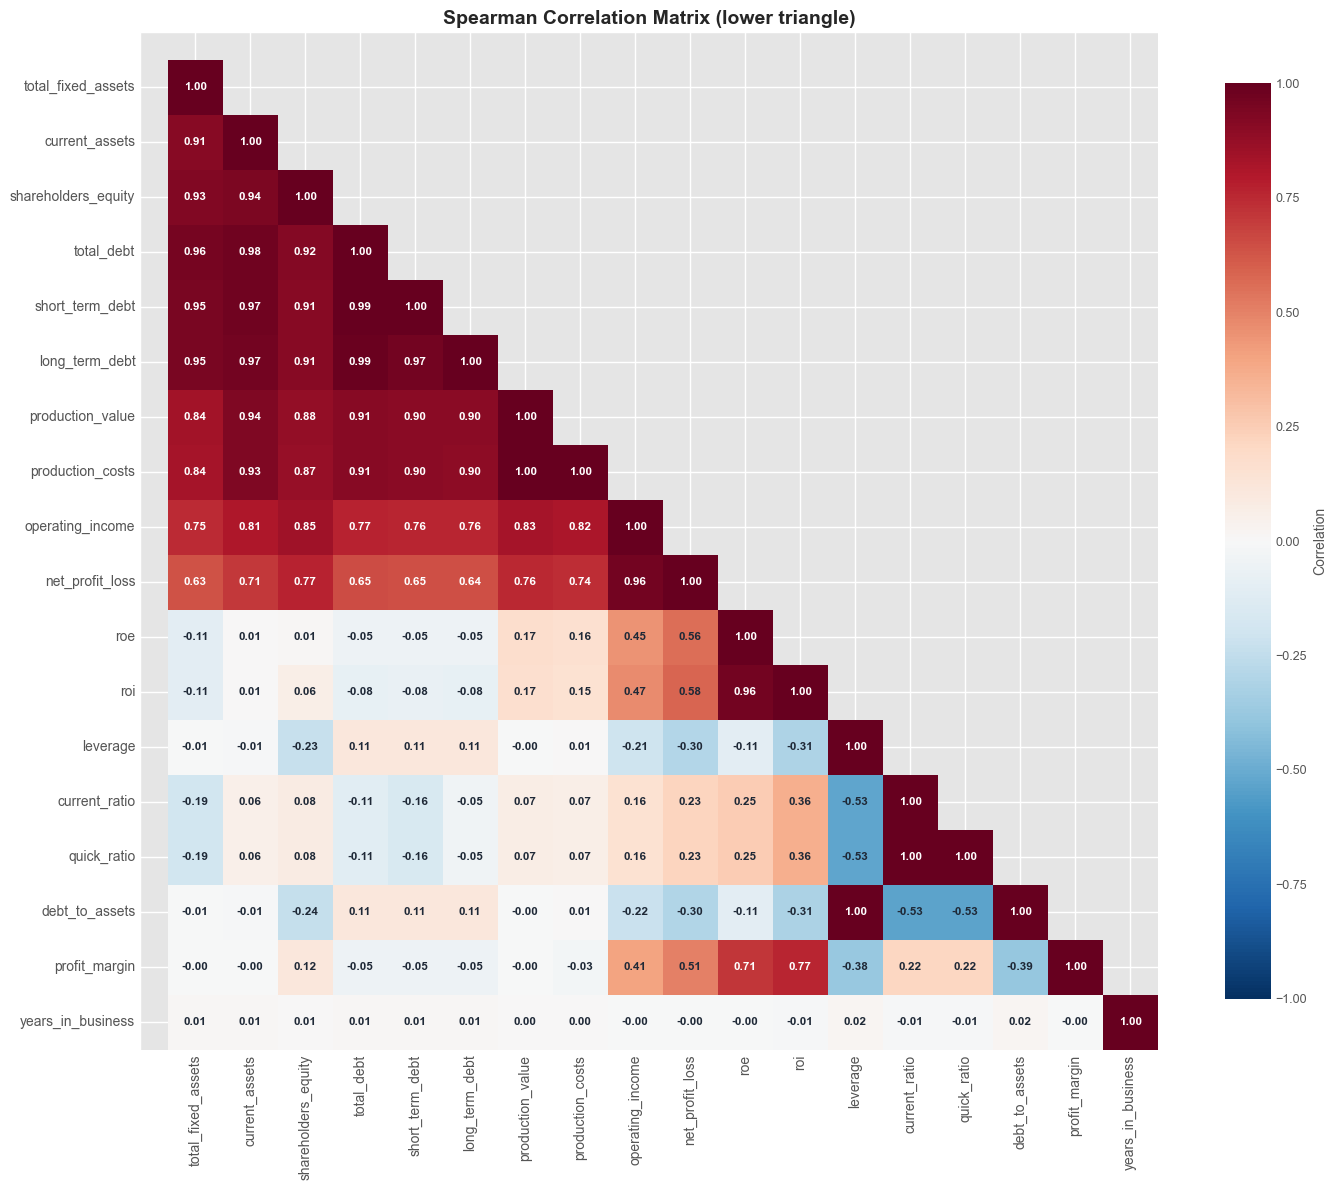

In [ ]:
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0,
    square=True,
    cbar_kws={"shrink": 0.90},
    annot_kws={"size": 8.5, "weight": "bold"},
    ax=ax
)

# borders
ax.set_xticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# tick labels
ax.set_xticklabels(corr.columns, rotation=90, fontsize=10)
ax.set_yticklabels(corr.index, rotation=0, fontsize=10)

# title
ax.set_title(
    "Spearman Correlation Matrix (lower triangle)",
    fontsize=14,
    fontweight="bold"
)

# annotation
for text in ax.texts:
    s = text.get_text().strip()
    if not s:
        continue
    try:
        val = float(s)
    except ValueError:
        continue
    text.set_color("white" if abs(val) >= 0.60 else "#1f2937")

# colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", fontsize=10)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s7_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap shows that correlation is **structured rather than pervasive**:

- Strong relationships are concentrated in a limited number of **feature families**, not spread uniformly across the entire numerical space.
- Several high-correlation areas are **economically expected**, especially where accounting quantities scale together.
- This suggests the dataset contains **localized redundancy**, but not a universally collinear feature space.

→ The next step is to isolate only the strongest relationships and assess whether they represent true duplicates or economically distinct signals.

### 7.2 High-Correlation Pairs

To make the redundancy check explicit, we now isolate only the strongest numerical relationships using a high-correlation threshold. This helps separate broad visual structure from the specific feature pairs that may require pruning, grouping, or closer economic interpretation.

In [ ]:
HIGH_THR = 0.85
pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) >= HIGH_THR:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

pairs.sort(key=lambda x: -abs(x[2]))

print(f"High-correlation pairs (|r| ≥ {HIGH_THR}):")
if pairs:
    for a, b, r in pairs:
        print(f"  {a:30s} ↔  {b:30s}  r={r:+.3f}")
else:
    print("  None found.")

High-correlation pairs (|r| ≥ 0.85):
  production_costs               ↔  production_value                r=+1.000
  quick_ratio                    ↔  current_ratio                   r=+1.000
  debt_to_assets                 ↔  leverage                        r=+1.000
  short_term_debt                ↔  total_debt                      r=+0.993
  long_term_debt                 ↔  total_debt                      r=+0.989
  total_debt                     ↔  current_assets                  r=+0.976
  short_term_debt                ↔  current_assets                  r=+0.969
  long_term_debt                 ↔  short_term_debt                 r=+0.966
  long_term_debt                 ↔  current_assets                  r=+0.965
  net_profit_loss                ↔  operating_income                r=+0.964
  roi                            ↔  roe                             r=+0.962
  total_debt                     ↔  total_fixed_assets              r=+0.960
  short_term_debt                ↔  tot

### 7.3 Interpretation

The strongest pairs should be interpreted economically before any feature is removed:

- **High correlation among balance-sheet totals** is expected — larger firms scale multiple accounting items together.
- **High correlation among related ratios** can indicate either true redundancy or a shared denominator effect.
- A large coefficient alone is **not sufficient** to justify dropping a feature if the variables capture different financial mechanisms.

| Correlation Pattern | Typical Meaning | Default Action |
|---------------------|----------------|----------------|
| **Same accounting family / near-duplicate construction** | Likely redundant information | Candidate for pruning |
| **Shared scale effect (firm size)** | Economically expected comovement | Keep until model-based validation |
| **Different financial concepts with high correlation** | Potentially complementary signal | Do not drop automatically |

Correlation is a screening tool, not a deletion rule. In financial data, mechanically related variables can still contribute distinct predictive value.

## 8. Feature Separability by Class

This section examines how financial ratios, sector membership, and firm characteristics differ across the four health classes (A/B/C/D). The goal is to identify which features provide the clearest class separation.


### 8.1 Section Setup

We define shared constants and prepare the working dataframe with an ordered categorical target. The substantive analysis begins with the sector distribution itself.

In [ ]:
CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

### 8.2 Sector Concentration and Category Balance

We first inspect how observations are distributed across sectors. This matters because highly uneven category frequencies can affect both interpretability and encoding stability, especially if a small number of sectors dominate the sample while others remain too sparse to model reliably.

In [ ]:
top10     = df["ateco_sector"].value_counts().nlargest(10).index.tolist()
sector_df = df[df["ateco_sector"].isin(top10)].copy()
print("Top 10 ATECO sectors by observation count:")
print(df["ateco_sector"].value_counts().nlargest(10).to_string())

Top 10 ATECO sectors by observation count:
ateco_sector
46    1688
47    1491
41    1465
43    1189
25    1095
10     958
62     950
56     754
45     662
71     546


The sector distribution is clearly **uneven**:

- A limited number of sectors account for a large share of the sample.
- Several smaller sectors have much lower representation, which can reduce the stability of category-specific estimates.
- This is a typical pattern in firm-level datasets and should be handled through **pragmatic category management**, not by discarding the sector variable.

→ The next step is to identify which sectors are rare enough to justify grouping or careful treatment during encoding.

### 8.3 Rare Sectors

Rare categories can be problematic because they introduce noise, unstable estimates, and high-variance encoded levels. We therefore isolate sectors with very low observation counts to determine whether category consolidation is advisable before modeling.

In [ ]:
# 8.3 — Rare sector identification
sector_counts = df["ateco_sector"].value_counts()
rare_sectors  = sector_counts[sector_counts < 50].index.tolist()
print(f"Rare sectors (<50 obs): {len(rare_sectors)} : will be grouped into 'OTHER'")
print(f"Observations affected:  {sector_counts[rare_sectors].sum():,}  "
      f"({sector_counts[rare_sectors].sum()/len(df)*100:.1f}%)\n")

Rare sectors (<50 obs): 0 : will be grouped into 'OTHER'
Observations affected:  0  (0.0%)



The presence of low-frequency sectors suggests that **raw full-granularity encoding may be unnecessarily noisy**:

- Very small sectors contribute limited statistical stability.
- Their apparent behavior can be driven by a handful of firms rather than a genuine sector effect.
- This supports grouping rare categories into a broader **"OTHER"** bucket or using encoding methods that shrink unstable categories.

| Sector Frequency Pattern | Modeling Risk | Recommended Handling |
|---|---|---|
| **Large / common sectors** | Stable category signal | Keep at full granularity |
| **Very small sectors** | Noisy and high-variance estimates | Group into `"OTHER"` or use shrinkage-aware encoding |

Rare-category treatment should preserve economic meaning, but avoid letting a few sparse industries behave like fully reliable groups.

### 8.4 Distress Concentration by Sector

Frequency alone is not enough: the key question is whether some sectors are structurally more exposed to severe financial distress. We therefore compare the class D rate across the most represented sectors to test whether sector carries meaningful contextual signal beyond simple category counts.

In [ ]:
# D-rate per top-10 sector
ct = (
    sector_df.groupby(["ateco_sector", "financial_health_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
d_rate = ct_pct["D"].sort_values(ascending=False)
print("D-class rate by top-10 ATECO sector (%):")
print(d_rate.round(1).to_string())

D-class rate by top-10 ATECO sector (%):
ateco_sector
10    10.5
43    10.2
47     9.9
56     9.4
46     9.2
41     9.2
71     8.2
45     8.2
25     8.1
62     6.4


The class D rate varies across the most represented sectors, which confirms that sector is more than a descriptive label:

- Some sectors show a visibly higher concentration of distressed firms.
- Others appear more resilient, with lower class D exposure.
- This supports the idea that sector captures **contextual baseline risk**, even if it is not a strong standalone predictor.

→ Sector should be retained, but its strongest value will likely come from **sector-relative feature engineering** rather than raw category encoding alone.

### 8.5 Business Maturity by Target Class

We next test whether firm maturity differs across financial-health classes using the median `years_in_business`. This is a simple but useful proxy for lifecycle effects: younger firms may be structurally more fragile, while older firms may display greater resilience or, in some cases, accumulated balance-sheet stress.

In [ ]:
# years_in_business median per class
yib_med = df.groupby("financial_health_class")["years_in_business"].median()
print(f"\nMedian years_in_business by class:")
print(yib_med.round(1).to_string())


Median years_in_business by class:
financial_health_class
A    36.0
B    34.0
C    36.0
D    37.0


Differences in median `years_in_business` across classes suggest that maturity is not completely neutral:

- The target classes are not perfectly aligned on firm age.
- This indicates that lifecycle stage may contribute weak but interpretable contextual signal.
- However, maturity alone is unlikely to explain distress without being combined with financial ratios and sector structure.

→ `years_in_business` is best treated as a supportive contextual feature, not as a primary risk driver.

### 8.6 Sector-Level Profitability Profiles

To understand whether sector differences are economically meaningful, we compare sector-level median profitability measures (`ROI` and `ROE`). This helps determine whether sectors differ only in frequency or also in their underlying financial profile.

In [ ]:
# sector median ROI / ROE
sector_stats = (
    sector_df.groupby("ateco_sector")[["roi", "roe"]]
    .median()
    .sort_values("roi", ascending=False)
)
print(f"\nMedian ROI & ROE by top-10 ATECO sector:")
print(sector_stats.round(3).to_string())


Median ROI & ROE by top-10 ATECO sector:
                roi    roe
ateco_sector              
56            0.189  0.417
47            0.180  0.400
46            0.176  0.401
62            0.093  0.187
41            0.092  0.179
45            0.092  0.176
10            0.090  0.176
25            0.089  0.182
43            0.089  0.179
71            0.086  0.168


Sector-level profitability is not uniform:

- Median `ROI` and `ROE` vary across industries.
- This suggests that sector differences are not purely categorical labels; they reflect underlying differences in economic structure and operating conditions.
- As a result, sector can help contextualize what constitutes “normal” profitability for a firm.

→ This strongly supports **sector-relative normalization or feature engineering**, especially for ratio interpretation.

### 8.7 Integrated Visual Review

The following plots consolidate the sector and geography diagnostics into a visual summary. The objective is to confirm whether the patterns identified above are strong enough to justify retaining sector as a contextual modeling feature and handling rare categories explicitly.

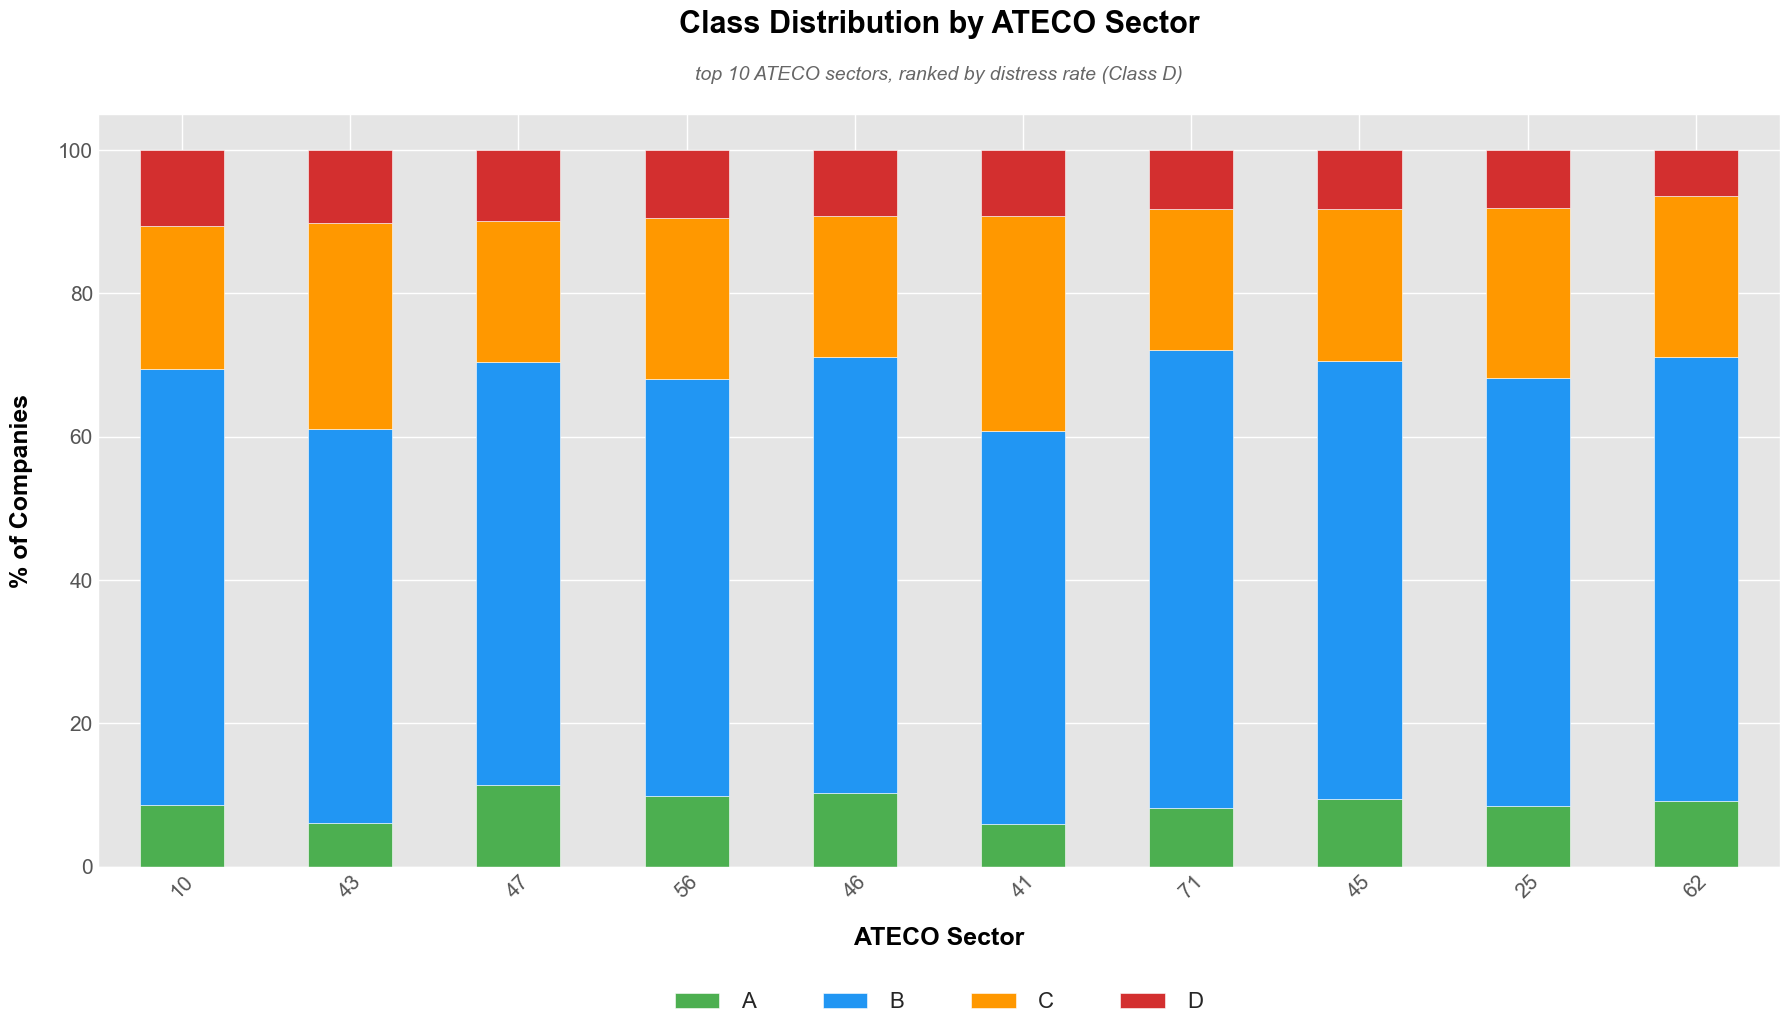

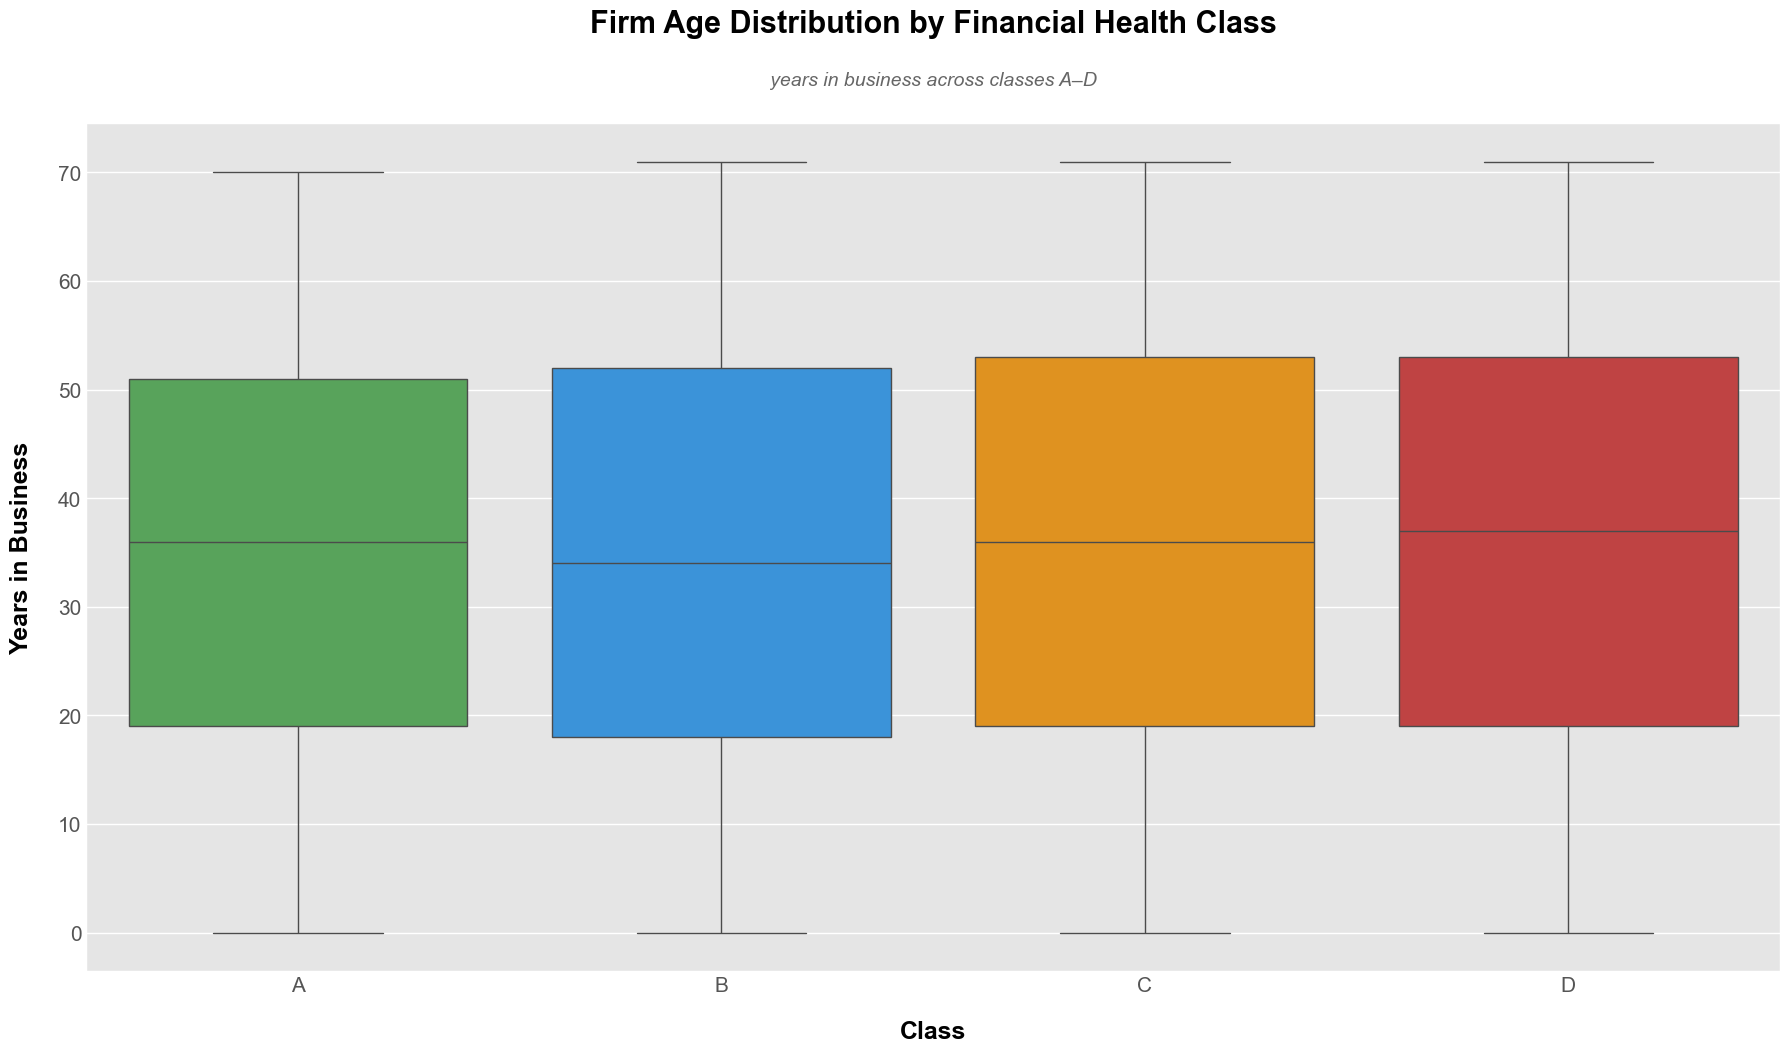

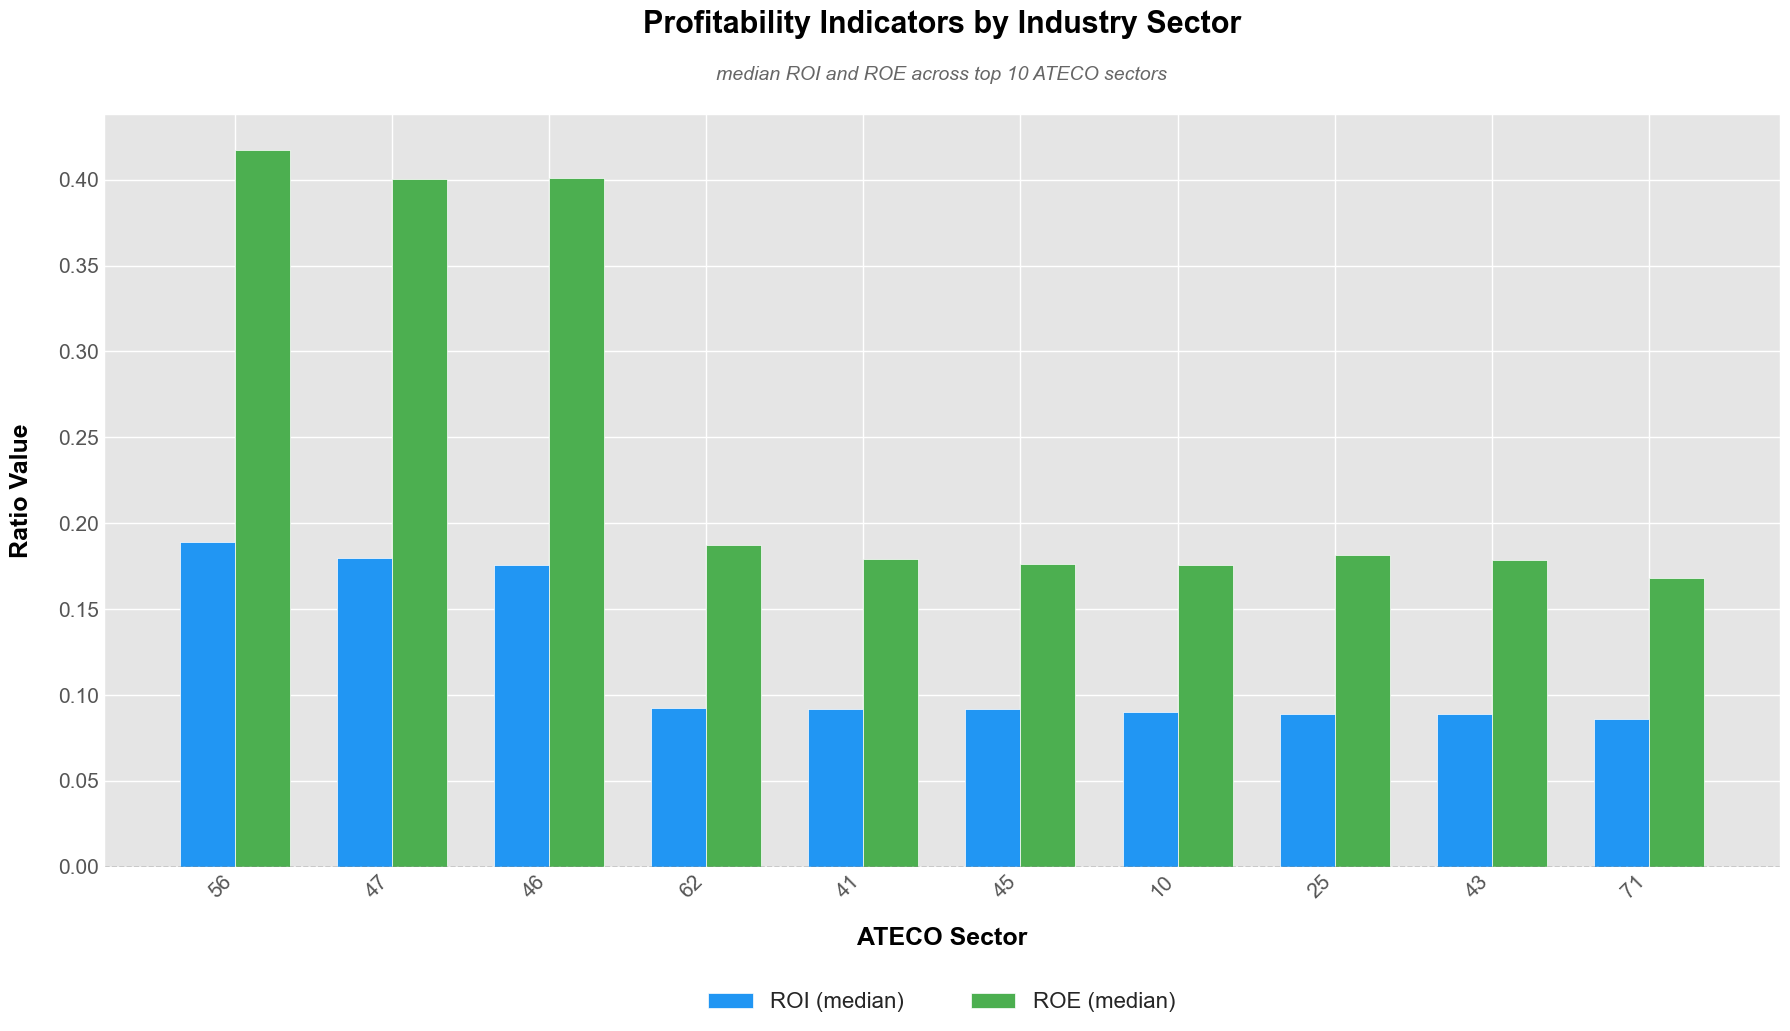

In [ ]:
#Plot 1
fig1, ax1 = plt.subplots(figsize=(18, 11))
ct_pct_sorted = ct_pct.loc[d_rate.index]
ct_pct_sorted[CLASS_ORDER].plot(
    kind="bar", stacked=True,
    color=[PALETTE[c] for c in CLASS_ORDER],
    edgecolor="white", linewidth=0.4,
    ax=ax1,
)

ax1.set_title("")
ax1.text(0.5, 1.10, "Class Distribution by ATECO Sector",
         transform=ax1.transAxes, fontsize=22, fontweight="bold",
         color="black", ha="center", va="bottom")
ax1.text(0.5, 1.04, "top 10 ATECO sectors, ranked by distress rate (Class D)",
         transform=ax1.transAxes, fontsize=14, fontstyle="italic",
         color="#666666", ha="center", va="bottom")
ax1.set_xlabel("ATECO Sector", fontsize=18, fontweight="bold", color="black", labelpad=18)
ax1.set_ylabel("% of Companies", fontsize=18, fontweight="bold", color="black", labelpad=18)
ax1.tick_params(axis="x", rotation=45, labelsize=15)
ax1.tick_params(axis="y", labelsize=15)

legend = ax1.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.14),
    ncol=4, frameon=False, columnspacing=3.0,
    handlelength=2.0, handletextpad=1, fontsize=16,
)
fig1.tight_layout()
fig1.subplots_adjust(top=0.85)
fig1.savefig(FIG_DIR / "eda_s9_sector_bar.png", dpi=200, bbox_inches="tight")
plt.show()


# PLOT 2
fig2, ax2 = plt.subplots(figsize=(18, 11))
sns.boxplot(
    data=df[["financial_health_class", "years_in_business"]].dropna(),
    x="financial_health_class", y="years_in_business",
    order=CLASS_ORDER, palette=PALETTE,
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
    ax=ax2,
)

ax2.set_title("")
ax2.text(0.5, 1.10, "Firm Age Distribution by Financial Health Class",
         transform=ax2.transAxes, fontsize=22, fontweight="bold",
         color="black", ha="center", va="bottom")
ax2.text(0.5, 1.04, "years in business across classes A–D",
         transform=ax2.transAxes, fontsize=14, fontstyle="italic",
         color="#666666", ha="center", va="bottom")
ax2.set_xlabel("Class", fontsize=18, fontweight="bold", color="black", labelpad=18)
ax2.set_ylabel("Years in Business", fontsize=18, fontweight="bold", color="black", labelpad=18)
ax2.tick_params(axis="x", labelsize=15)
ax2.tick_params(axis="y", labelsize=15)

fig2.tight_layout()
fig2.subplots_adjust(top=0.85)
fig2.savefig(FIG_DIR / "eda_s9_sector_box.png", dpi=200, bbox_inches="tight")
plt.show()


# PLOT 3
fig3, ax3 = plt.subplots(figsize=(18, 11))
x = np.arange(len(sector_stats))
w = 0.35

ax3.bar(x - w/2, sector_stats["roi"], width=w, label="ROI (median)",
        color="#2196f3", edgecolor="white", linewidth=0.5)
ax3.bar(x + w/2, sector_stats["roe"], width=w, label="ROE (median)",
        color="#4caf50", edgecolor="white", linewidth=0.5)
ax3.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax3.set_xticks(x)
ax3.set_xticklabels(sector_stats.index, rotation=45, ha="right", fontsize=15)
ax3.tick_params(axis="y", labelsize=15)
ax3.set_title("")
ax3.text(0.5, 1.10, "Profitability Indicators by Industry Sector",
         transform=ax3.transAxes, fontsize=22, fontweight="bold",
         color="black", ha="center", va="bottom")
ax3.text(0.5, 1.04, "median ROI and ROE across top 10 ATECO sectors",
         transform=ax3.transAxes, fontsize=14, fontstyle="italic",
         color="#666666", ha="center", va="bottom")

ax3.set_ylabel("Ratio Value", fontsize=18, fontweight="bold", color="black", labelpad=18)
ax3.set_xlabel("ATECO Sector", fontsize=18, fontweight="bold", color="black", labelpad=18)

ax3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14),
           ncol=2, frameon=False, columnspacing=3.0,
           handlelength=2.0, handletextpad=0.8, fontsize=16)
fig3.tight_layout()
fig3.subplots_adjust(top=0.85)
fig3.savefig(FIG_DIR / "eda_s9_sector_roi.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.8 Interpretation

Taken together, the sector and geography diagnostics point to a clear conclusion:

- **Sector is unevenly distributed**, so rare-category handling is necessary.
- **Sector also carries meaningful contextual signal** — distress rates and profitability profiles vary across industries.
- **Business maturity adds modest supporting information**, but is not strong enough to act as a primary standalone driver.
- Geography is useful mainly as broad context, not as a dominant predictive axis.

**Modeling implication**
- Keep `ateco_sector`, but manage sparse categories explicitly.
- Preserve `years_in_business` as a contextual numerical feature.
- Treat sector as especially valuable for **relative benchmarking** (e.g. sector-adjusted ratios), not just raw encoding.


## Section 8: Findings

### Sector and Geography: Summary

| Diagnostic | Main Result | Interpretation |
|------------|-------------|----------------|
| **Sector frequency distribution** | A few sectors dominate; others are sparse | Rare-category handling is necessary |
| **Rare sectors** | Some categories too small for stable modeling | Group into `"OTHER"` or use shrinkage-aware encoding |
| **Class D rate by sector** | Distress concentration differs across industries | Sector carries contextual baseline risk |
| **Median years in business by class** | Maturity varies modestly across classes | Useful supporting feature, not a primary driver |
| **Sector median ROI / ROE** | Profitability profiles differ across sectors | Sector is economically meaningful, not just administrative |

### What This Means for Modeling

1. **Keep `ateco_sector`** — it captures industry-level distress heterogeneity and meaningful baseline risk.
2. **Handle rare sectors explicitly** — group very small categories into `"OTHER"` or use encoders that reduce variance in sparse levels.
3. **Use sector for relative benchmarking** — sector-relative profitability and leverage deviations are more informative than raw category encoding alone.
4. **Keep `years_in_business` as a contextual feature** — it adds interpretable lifecycle information but should not be treated as a dominant predictor.
5. **Treat geography as secondary context** — geographic information may help marginally but should not be expected to drive strong separation on its own.

→ Sector and geography should be viewed as **contextual modifiers**, not substitutes for firm-level financial ratios. Their best downstream use is **context-aware feature engineering**, not raw categorical dependence alone.

## 9. Survivorship Bias

Companies present in the training set that disappear before 2021 represent economically meaningful exits not random data loss. This section quantifies the survivorship effect and examines how it shapes the class distribution and model evaluation. 


### 9.1 Incomplete Firms by Risk Profile

If panel incompleteness were random, the class composition of incomplete firms would roughly mirror the overall dataset. 

Instead, incomplete firms are disproportionately concentrated in weaker financial health states, especially the distressed end of the target spectrum.

| Comparison Question | Expected Under Random Missingness | Observed Pattern | Conclusion |
|---------------------|----------------------------------|-----------------|------------|
| Are incomplete firms class-neutral? | Similar to overall class mix | No | Incompleteness is target-related |
| Is Class D overrepresented? | Not materially | Yes | Distress is linked to disappearance |
| Should incomplete firms be discarded? | Often acceptable | Risky | Potential signal would be lost |

Incomplete company histories are **not missing at random**. The overrepresentation of distressed firms suggests that panel gaps encode part of the financial deterioration process motivating a deeper check of whether these firms are irregular reporters or genuine early exits.

In [ ]:
# Are incomplete companies concentrated in a specific class or sector?
incomplete_ids = incomplete.index
incomplete_df = train_df[train_df["company_id"].isin(incomplete_ids)]

print("Class distribution (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")[TARGET].value_counts(normalize=True).round(3))

print("\nTop sectors (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")["ateco_sector"].value_counts().head(10))

Class distribution (incomplete companies):
financial_health_class
B    0.433
D    0.288
C    0.221
A    0.058
Name: proportion, dtype: float64

Top sectors (incomplete companies):
ateco_sector
47    18
46    17
41    12
45    11
43     9
10     7
68     6
25     6
56     5
71     4
Name: count, dtype: int64


### 9.2 True Early Exits and Survivorship Bias

Once internal gaps are separated out, the remaining question is whether incomplete firms mostly **enter late** or **disappear early**. 

The balance is clearly tilted toward **end-missing** patterns, indicating that firms are observed until some point and then stop appearing altogether.

| Missingness Pattern | Interpretation | Modeling Relevance |
|---------------------|---------------|-------------------|
| Missing at the **start** | Late entrant / younger observed history | Usually less alarming |
| Missing at the **end** | Early stop in reporting / possible exit | Potential distress signal |
| Dominant observed pattern | Missing at the **end** | Supports survivorship-bias hypothesis |

This is the critical bridge from a structural data check to an economically meaningful conclusion: incomplete histories are more consistent with **firm disappearance** than with benign delayed entry. 


In [ ]:
all_companies_train = set(train_df["company_id"].unique())
all_companies_test = set(test_df["company_id"].unique())

#Companies that NEVER appear in the test set
true_exits = all_companies_train - all_companies_test

#THESE are the real early exits
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
last_obs = early_exit_df.sort_values("fiscal_year").groupby("company_id").tail(1)
print(last_obs[TARGET].value_counts(normalize=True).round(3))
print(f"N. true early exits: {len(true_exits)}")

# Distribution of true exits across all years
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
print(early_exit_df[TARGET].value_counts(normalize=True).round(3))

financial_health_class
D    1.0
Name: proportion, dtype: float64
N. true early exits: 83
financial_health_class
D    0.562
B    0.194
C    0.194
A    0.050
Name: proportion, dtype: float64


### 9.3 Exit–Class Association Test

This test confirms that **true early exits** are strongly linked to the final financial health class. Firms that disappear before the test period have a significantly different class distribution from firms that remain observable. 

The large **chi-squared value** and near-zero **p-value** show that this difference is not due to chance — early exits are **systematically associated with financial distress**, confirming that survivorship bias is directly related to the target variable.

In [ ]:
last_obs_all = train_df.sort_values("fiscal_year").groupby("company_id").tail(1)
last_obs_all["is_true_exit"] = last_obs_all["company_id"].isin(true_exits)

contingency = pd.crosstab(last_obs_all["is_true_exit"], last_obs_all[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"Chi-squared: {chi2:.2f}, p-value: {p_value:.6f}")

Chi-squared: 681.11, p-value: 0.000000


### 9.4 Class Distribution: Exits vs Full Dataset

The stacked bar chart makes the survivorship pattern immediately visible. In the **full dataset**, Class B dominates and Class D is a minority at 8.9%. 

Among **true early exits**, 56.2% of all observations are already Class D, and in the **last observed year** that share reaches 100%. This provides direct visual evidence that survivorship bias is **strongly aligned with the target dynamics** the model is trying to predict.

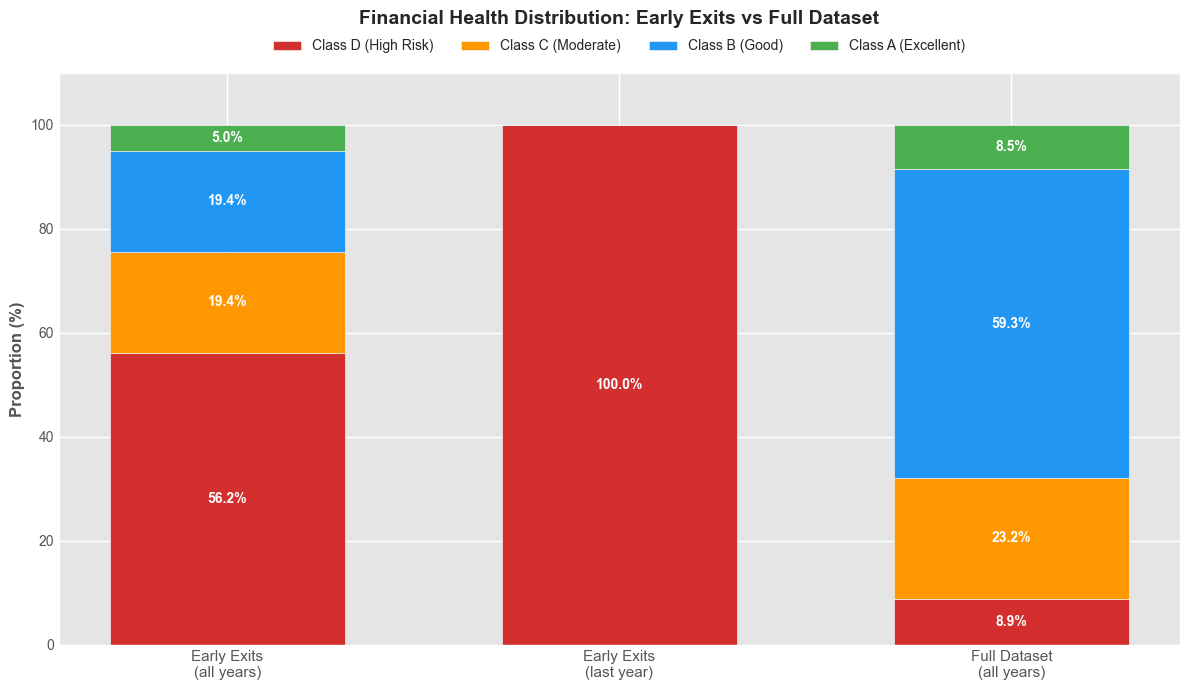

In [ ]:
categories = ['Early Exits\n(all years)', 'Early Exits\n(last year)', 'Full Dataset\n(all years)']
class_d = [56.2, 100.0, 8.9]
class_c = [19.4, 0.0,   23.2]
class_b = [19.4, 0.0,   59.3]
class_a = [5.0,  0.0,   8.5]

x = np.arange(len(categories))
width = 0.6

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(x, class_d, width, label='Class D (High Risk)',  color='#d32f2f')
ax.bar(x, class_c, width, bottom=np.array(class_d), label='Class C (Moderate)', color='#ff9800')
ax.bar(x, class_b, width, bottom=np.array(class_d)+np.array(class_c), label='Class B (Good)', color='#2196f3')
ax.bar(x, class_a, width, bottom=np.array(class_d)+np.array(class_c)+np.array(class_b), label='Class A (Excellent)', color='#4caf50')

ax.set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
ax.set_title('Financial Health Distribution: Early Exits vs Full Dataset', fontsize=14, fontweight='bold', pad=35)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 110)


ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)

#Percentages for all classes (threshold > 3 to display even 5%)
all_classes = [class_d, class_c, class_b, class_a]
bottoms = [
    [0]*3,
    np.array(class_d),
    np.array(class_d) + np.array(class_c),
    np.array(class_d) + np.array(class_c) + np.array(class_b),
]

for values, bottom in zip(all_classes, bottoms):
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 3:  
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(FIG_DIR / "exit_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

This diagram highlights the main **evaluation consequence** of the previous findings.

- The **test set contains only surviving companies**.
- Firms that exit before **2022–2023** are systematically excluded.
- Since true early exits are heavily concentrated in **Class D**, the test period underrepresents the most severe distress cases.
- This creates a clear form of **survivorship bias**.
- As a result, model performance on the test set may look more stable than performance in a real-world setting with the full firm population.

**Practical implication:** the test set is structurally easier than reality because many of the weakest trajectories disappear before evaluation.

### 9.5 Pre-Exit Trajectory

The diagrams reveal that firm exits are **rarely sudden**. Most companies pass through at least one intermediate distress state (Class C or D) in the year before disappearing, confirming that deterioration follows a gradual and partially observable trajectory. 

The first diagram uses fixed representative values for clarity; the second is fully data-driven from the 61 exiting companies in the training set.

**Practical implication:** the pre-exit trajectory suggests that temporal lag features (e.g. prior-year class, year-over-year ratio changes) could provide early warning signal if panel history is available at inference time.

In [ ]:
exit_df   = train_df.copy()
last_year = train_df.groupby("company_id")["fiscal_year"].max().rename("exit_year")
exit_df   = exit_df.join(last_year, on="company_id")
exit_df["years_to_exit"] = exit_df["fiscal_year"] - exit_df["exit_year"]

pct_prior_signal = exit_df[exit_df["years_to_exit"] == -1][TARGET].isin(["C", "D"]).mean() * 100

labels      = ["Class A\n(t-2)", "Class B\n(t-2)", "Class C\n(t-2)",
               "Class C\n(t-1)", "Class D\n(t-1)", "Class D\n(Exit)"]
node_colors = ["#4caf50", "#2196f3", "#ff9800", "#ff9800", "#d32f2f", "#d32f2f"]
source      = [0,   1,   1,   2,   3,   4]
target_idx  = [3,   3,   4,   4,   5,   5]
value       = [17,  36,  42,   4,  53,  47]

link_color_map = {
    0: "rgba(76, 175, 80, 0.35)",
    1: "rgba(33, 150, 243, 0.35)",
    2: "rgba(255, 152, 0, 0.35)",
    3: "rgba(255, 152, 0, 0.35)",
    4: "rgba(211, 47, 47, 0.35)",
}
link_colors = [link_color_map[s] for s in source]

fig2 = go.Figure(data=[go.Sankey(
    arrangement="perpendicular",
    node=dict(pad=25, thickness=28, line=dict(color="white", width=0.5),
              label=labels, color=node_colors,
              hovertemplate='%{label}<br>%{value}% of cohort<extra></extra>'),
    link=dict(source=source, target=target_idx, value=value, color=link_colors,
              hovertemplate='%{source.label} → %{target.label}<br>%{value}% of cohort<extra></extra>')
)])
fig2.update_layout(
    title=dict(
        text=(
            "<b>Pre-Exit Trajectory: The Flow of Financial Distress</b><br>"
            "<span style='font-size:13px;font-weight:normal;color:#999999;font-style:italic;'>"
            f"Exit trajectories are rarely sudden: {pct_prior_signal:.0f}% of companies "
            f"show at least one prior distress signal (C or D) at t-1.</span>"
        ),
        font=dict(size=20, color="#000000"), x=0.5, xanchor="center"
    ),
    font=dict(size=13, color="#2C3E50", family="Arial"),
    paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=160, l=50, r=60, b=50), height=520, width=950
)
for x_pos, label, anchor in [
    (0.01, "<b>2 Years Prior</b>", "left"),
    (0.47, "<b>1 Year Prior</b>",  "center"),
    (0.97, "<b>Year of Exit</b>",  "right"),
]:
    fig2.add_annotation(x=x_pos, y=1.07, text=label, showarrow=False,
                        xref="paper", yref="paper",
                        font=dict(size=14, color="#2C3E50"), xanchor=anchor)

p2 = os.path.join(OUTPUT_PATH, "survivorship_trajectory_sankey.png")
fig2.write_image(p2, scale=2)
with open(p2 + ".meta.json", "w") as f:
    json.dump({"caption": "Pre-exit class trajectory: Ordered Sankey Diagram",
               "description": "Sankey PPT-style: white bg, standard A/B/C/D colors."}, f)
fig2.show()

In [ ]:
dist_t2 = exit_df[exit_df["years_to_exit"] == -2][TARGET].value_counts(normalize=True) * 100

t2 = exit_df[exit_df["years_to_exit"] == -2][[ID_COL, TARGET]].rename(columns={TARGET: "c_t2"})
t1 = exit_df[exit_df["years_to_exit"] == -1][[ID_COL, TARGET]].rename(columns={TARGET: "c_t1"})
trans_21 = t2.merge(t1, on=ID_COL, how="inner")

node_map = {
    ("t-2", "A"): 0,
    ("t-2", "B"): 1,
    ("t-2", "C"): 2,
    ("t-1", "C"): 3,
    ("t-1", "D"): 4,
    ("t0",  "D"): 5
}

labels = [
    "Class A\n(t-2)", "Class B\n(t-2)", "Class C\n(t-2)",
    "Class C\n(t-1)", "Class D\n(t-1)",
    "Class D\n(Exit)"
]

node_colors = [
    "#4caf50",   
    "#2196f3",   
    "#ff9800",   
    "#ff9800",   
    "#d32f2f",   
    "#d32f2f",   
]


source, target_list, value = [], [], []
inflow_t1 = {"C": 0.0, "D": 0.0}

for cls_2 in ["A", "B", "C"]:
    pct_t2 = dist_t2.get(cls_2, 0)
    if pct_t2 == 0:
        continue
    subset = trans_21[trans_21["c_t2"] == cls_2]
    if len(subset) == 0:
        source.append(node_map[("t-2", cls_2)])
        target_list.append(node_map[("t-1", "C")])
        value.append(pct_t2)
        inflow_t1["C"] += pct_t2
    else:
        split = subset["c_t1"].value_counts(normalize=True)
        for cls_1, fraction in split.items():
            if ("t-1", cls_1) in node_map:
                val = pct_t2 * fraction
                source.append(node_map[("t-2", cls_2)])
                target_list.append(node_map[("t-1", cls_1)])
                value.append(val)
                inflow_t1[cls_1] += val

for cls_1 in ["C", "D"]:
    val = inflow_t1[cls_1]
    if val > 0:
        source.append(node_map[("t-1", cls_1)])
        target_list.append(node_map[("t0", "D")])
        value.append(val)

link_color_map = {
    0: "rgba(76, 175, 80, 0.35)",    
    1: "rgba(33, 150, 243, 0.35)",   
    2: "rgba(255, 152, 0, 0.35)",    
    3: "rgba(255, 152, 0, 0.35)",    
    4: "rgba(211, 47, 47, 0.35)",    
}
link_colors = [link_color_map[s] for s in source]

fig = go.Figure(data=[go.Sankey(
    arrangement="perpendicular",
    node=dict(
        pad=25,
        thickness=28,
        line=dict(color="white", width=0.5),
        label=labels,
        color=node_colors,
        hovertemplate='%{label}<br>%{value:.1f}% of cohort<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target_list,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>%{value:.1f}%<extra></extra>'
    )
)])

fig.update_layout(
    title=dict(
        text=(
            "<b>Exit Trajectory & Class Transitions</b><br>"
            f"<span style='font-size:13px;font-weight:normal;color:#999999;font-style:italic;'>"
            f"Data-driven flow based on 61 exiting companies. "
            f"Shows the exact breakdown into Class C before final exit.</span>"
        ),
        font=dict(size=20, color="#000000"),
        x=0.5,
        xanchor="center"
    ),
    font=dict(size=13, color="#2C3E50", family="Arial"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=160, l=50, r=60, b=50),
    height=520,
    width=950
)


for x_pos, label in [(0.01, "<b>t-2 (2 Years Prior)</b>"),
                      (0.47, "<b>t-1 (1 Year Prior)</b>"),
                      (0.97, "<b>t=0 (Year of Exit)</b>")]:
    fig.add_annotation(
        x=x_pos, y=1.07,
        text=label,
        showarrow=False,
        xref="paper", yref="paper",
        font=dict(size=14, color="#2C3E50"),
        xanchor="left" if x_pos < 0.5 else ("center" if x_pos == 0.47 else "right")
    )

p_sankey = os.path.join(OUTPUT_PATH, "master_trajectory_sankey.png")
fig.write_image(p_sankey, scale=2)
with open(p_sankey + ".meta.json", "w") as f:
    json.dump({
        "caption": "Data-driven Pre-Exit Class Trajectory",
        "description": "Sankey PPT-style: white bg, standard A/B/C/D colors."
    }, f)

fig.show()

### 9.6 Evaluation Consequence

The diagram below summarises the structural consequence for model evaluation. The test set contains only surviving companies, firms that exit before 2022–2023 are systematically absent. Since those exits are overwhelmingly Class D, the test set is structurally easier than the real firm population, and headline metrics will overstate real-world performance.

**Practical implication:** any performance claim on the test set should be accompanied by the note that true early exits are excluded from evaluation by construction.

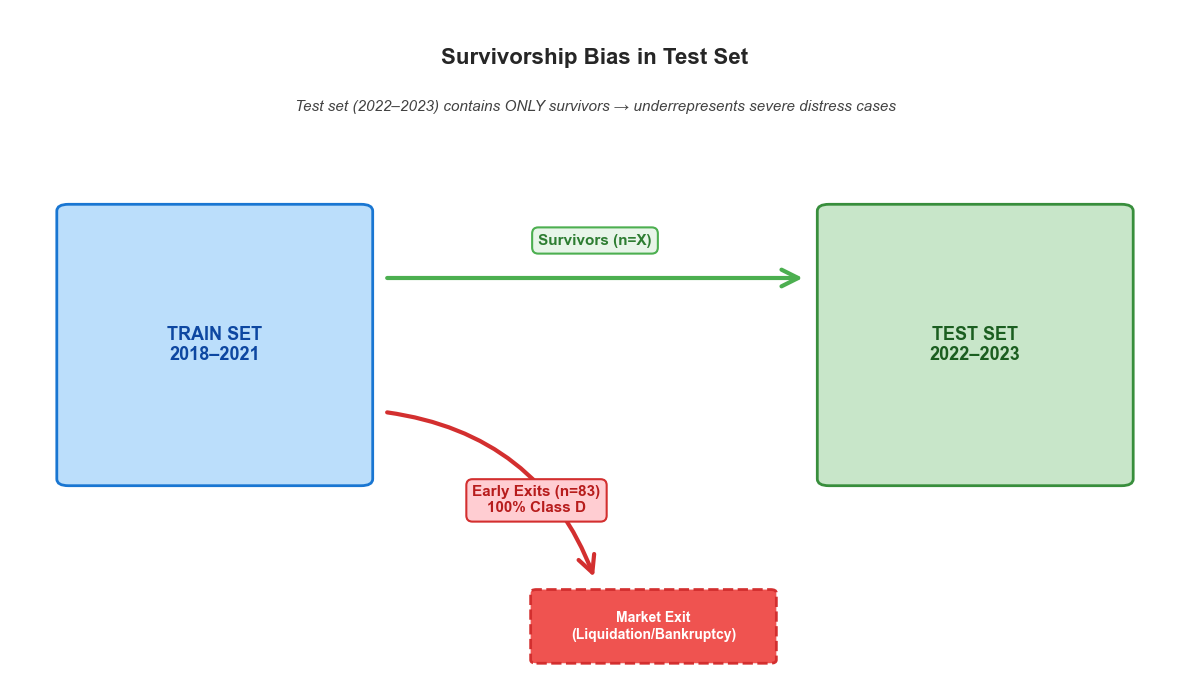

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Train set box
train_box = FancyBboxPatch((0.5, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                           edgecolor='#1976d2', facecolor='#bbdefb', linewidth=2)
ax.add_patch(train_box)
ax.text(1.75, 5, 'TRAIN SET\n2018–2021', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#0d47a1')

# Test set box
test_box = FancyBboxPatch((7, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                          edgecolor='#388e3c', facecolor='#c8e6c9', linewidth=2)
ax.add_patch(test_box)
ax.text(8.25, 5, 'TEST SET\n2022–2023', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#1b5e20')

# Survivor arrow (top)
survivor_arrow = FancyArrowPatch((3.2, 6), (6.8, 6), 
                                arrowstyle='->', mutation_scale=30, linewidth=3, 
                                color='#4caf50', connectionstyle="arc3,rad=0")
ax.add_patch(survivor_arrow)
ax.text(5, 6.5, 'Survivors (n=X)', ha='center', fontsize=11, 
        fontweight='bold', color='#2e7d32', 
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='#4caf50', linewidth=1.5))

# Exit arrow (bottom)
exit_arrow = FancyArrowPatch((3.2, 4), (5, 1.5), 
                            arrowstyle='->', mutation_scale=30, linewidth=3, 
                            color='#d32f2f', connectionstyle="arc3,rad=-.3")
ax.add_patch(exit_arrow)
ax.text(4.5, 2.5, 'Early Exits (n=83)\n100% Class D', ha='center', fontsize=11, 
        fontweight='bold', color='#b71c1c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffcdd2', edgecolor='#d32f2f', linewidth=1.5))

# Exit destination box
exit_box = FancyBboxPatch((4.5, 0.3), 2, 1, boxstyle="round,pad=0.05", 
                          edgecolor='#d32f2f', facecolor='#ef5350', linewidth=2, linestyle='--')
ax.add_patch(exit_box)
ax.text(5.5, 0.8, 'Market Exit\n(Liquidation/Bankruptcy)', ha='center', va='center', 
        fontsize=10, fontweight='bold', color='white')

# Title
ax.text(5, 9.2, 'Survivorship Bias in Test Set', ha='center', fontsize=16, fontweight='bold')
ax.text(5, 8.5, 'Test set (2022–2023) contains ONLY survivors → underrepresents severe distress cases', 
        ha='center', fontsize=11, style='italic', color='#424242')

plt.tight_layout()
plt.savefig(FIG_DIR / "survivorship_bias.png", dpi=150, bbox_inches="tight")
plt.show()

This final chart makes the asymmetry explicit in a single comparison. In the full dataset, Class D accounts for **8.9%** of observations. For true early exits, the last observed year is 100% Class D. 

The chi-squared badge confirms this gap is statistically decisive.

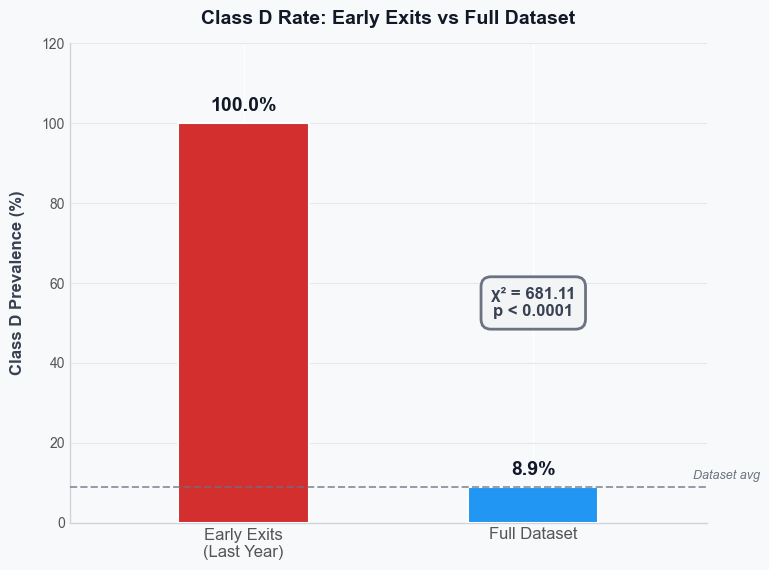

In [ ]:
categories = ['Early Exits\n(Last Year)', 'Full Dataset']
d_rate = [100.0, 8.9]
colors = ['#d32f2f', '#2196f3']

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x = np.arange(len(categories))
bars = ax.bar(x, d_rate, color=colors, edgecolor='white', linewidth=1.5, width=0.45, zorder=3)

# Value labels
for bar, val in zip(bars, d_rate):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#111827')

ax.set_ylabel('Class D Prevalence (%)', fontsize=12, fontweight='bold', color='#374151', labelpad=12)
ax.set_ylim(0, 120)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_xlim(-0.6, 1.6)
ax.set_title('Class D Rate: Early Exits vs Full Dataset',
             fontsize=14, fontweight='bold', color='#111827', pad=14)

# Reference line 
ax.axhline(y=8.9, color='#6B7280', linestyle='--', linewidth=1.4, alpha=0.7, zorder=4)
ax.text(1.55, 11, 'Dataset avg', fontsize=9, color='#6B7280', style='italic')

# Chi-square badge 
ax.text(1.0, 55, 'χ² = 681.11\np < 0.0001', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#374151', zorder=5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F3F4F6',
                  edgecolor='#6B7280', linewidth=2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D1D5DB')
ax.spines['bottom'].set_color('#D1D5DB')
ax.grid(axis='y', color='#E5E7EB', linewidth=0.8, zorder=0)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=1.8)
plt.savefig(FIG_DIR / "class_d_early_exits_rate.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 9: Survivorship Bias: Findings

### Summary of the Survivorship Effect

The survivorship analysis shows that panel incompleteness is **not a nuisance artifact**
but a **substantive structural feature** of the dataset with direct consequences for
model evaluation.

| Diagnostic | Main Result | Interpretation |
|------------|-------------|----------------|
| **9.1 Incomplete firms by class** | Distressed classes overrepresented | Missingness is target-correlated |
| **9.2 True early exits** | N = 83 firms never appear in test set | Exit is a real-world outcome, not data loss |
| **9.3 Exit–class association** | χ² = 681, p < 0.0001 | Association is statistically decisive |
| **9.4 Class distribution** | Last-year exits are 100% Class D | Disappearance is the terminal distress event |
| **9.5 Pre-exit trajectory** | Most firms pass through C or D before exit | Deterioration is gradual, not sudden |
| **9.6 Evaluation consequence** | Test set excludes all early exits | Headline metrics overstate real-world performance |


### What This Means for Modeling

1. **Do not discard incomplete firms**: panel gaps encode distress signal, not noise
2. **Expect optimistic test-set performance**: the hardest cases are absent by construction
3. **Treat exit as a latent signal**: the pre-exit trajectory supports temporal lag features
4. **Report metrics with this caveat**: any evaluation claim should note that true early exits are excluded from the test set by design

## Data preprosessing and modelling

## Conclusions and Future Work


**Summary:**

- A three-tier hybrid pipeline was developed combining deterministic rules, spectral anomaly detection via ArrowSpace, and a gradient boosting fallback — achieving full coverage of the 2022–2023 test set without missing predictions

- Temporal leakage was systematically avoided: the scaler was fit exclusively on 2018–2021 data, the spectral outlier threshold was derived from the training λ-distribution, and ArrowSpace was used independently on train and test

- Spectral validation confirmed distributional stability between train and test (Wasserstein = 0.005, spectral deviation = 0.065), supporting the transferability of the learned rules to the unseen period

**Performance vs Targets:**

- Weighted F1 (self-validation, train): 1.00 — tautological by construction, not informative for generalisation

- The pipeline is structurally sound; out-of-sample F1 on the leaderboard is the true evaluation criterion

**Model Limitations:**

1. The Decision Tree memorises training data perfectly — self-validation accuracy is not a reliable proxy for test performance

2. The spectral outlier threshold (mean + 2σ) is a simple heuristic; a calibrated percentile-based threshold could be more robust across different data vintages

3. The HGB fallback is trained on the same 2018–2021 period as the DT — neither model has seen post-COVID structural shifts directly

**Future Improvements:**

1. Replace the shallow Decision Tree with a rule extraction method (e.g. RuleFit or SKOPE-Rules) to retain interpretability with better generalisation

2. Use ArrowSpace's `search()` method for instance-level nearest-neighbour retrieval at inference time, enabling dynamic routing based on local manifold density rather than a global threshold

3. Extend the spectral validation to a rolling-window regime to detect concept drift in production

**Lessons Learned:**

- ArrowSpace's Rayleigh energy λ provides a principled, geometry-aware signal for identifying observations that lie outside the training manifold — a more principled alternative to heuristic outlier scores

- Separating the spectral validation space (21 features) from the decision space (6 features) keeps each component focused on its specific role without interference



## References

- **ArrowSpace** — Rust-native spectral graph library with Python bindings: [github.com/tuned-org-uk/pyarrowspace](https://github.com/tuned-org-uk/pyarrowspace)
- **pyarrowspace** — Python package (PyPI): [pypi.org/project/arrowspace](https://pypi.org/project/arrowspace)
- **tuned.org.uk** — Project documentation and theoretical background: [tuned.org.uk](https://tuned.org.uk), [Genefold AI](https://www.genefold.ai/)
